<a href="https://colab.research.google.com/github/MAngelica-Sandoval/Proyecto-Analisis-de-Datos-NORM/blob/main/sesiones_practicas/sp_3_maria_sandoval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# <span style="color:#2F749F;"><strong>📦 Sesión práctica 3: Codificación y transformación de variables</strong></span>
---
<p align="left">
  <a href="https://colab.research.google.com/github/mariabda2/intro_data_2026/blob/main/sesiones_practicas/sp_3_maria_bernarda_salazar.ipynb?clone=true" target="_blank">
    <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Abrir en Colab"/>
  </a>
</p>

# Analisis de datos Modaria II.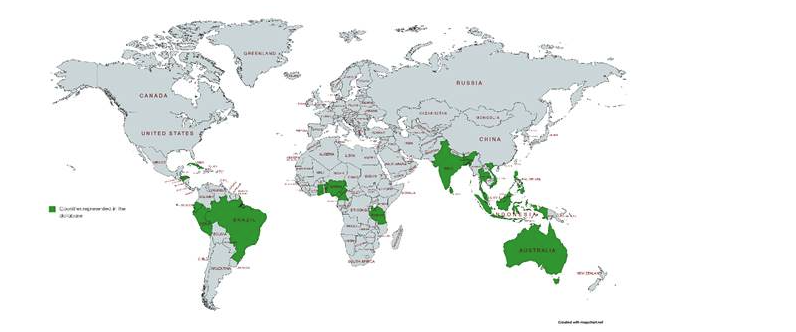

La pregunta de investigación a lo largo de todos los ejercicios del curso es: ¿Cómo se relaciona la presencia de metales pesados y las propiedades del suelo con la absorción y acumulación de radionúclidos en los diferentes compartimentos de las plantas tropicales (raíz, tallo y hojas)?


Este estudio analiza las concentraciones de metales pesados en suelos y plantas usando el conjunto de datos IAEA MODARIA II Tropical, que recopila mediciones de transferencia de contaminantes en ecosistemas tropicales.
Se seleccionaron tres elementos: Plomo (Pb), Zinc (Zn) y Cobre (Cu), con medianas de C_soil entre 17 y 38.5 mg/kg y más de 300 registros por cada uno, garantizando una buena representatividad estadística y comparabilidad.
Se aplicaron cinco métodos de escalamiento (StandardScaler, MinMaxScaler, RobustScaler y Z-Score), normalización (L1 y L2) y varias transformaciones para reducir la asimetría (logarítmica, log reflejada, cuadrática, Box-Cox, raíz cuadrada, recíproca y Yeo-Johnson) en la variable C_soil. El propósito es determinar qué técnicas conservan mejor la estructura real de los datos en presencia de una fuerte asimetría positiva y valores atípicos extremos comunes en las variables ambientales relacionadas con la contaminación por metales pesados.

## <span style="color:#2F749F;"><strong>Ejercicio 1: Comparación de métodos de escalamiento</strong></span>

A partir de un conjunto de datos real, analiza cómo cambia la escala de las variables al aplicar diferentes métodos de **escalamiento de datos**, y compara visualmente sus efectos sobre la distribución.
1. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - `StandardScaler`
   - `MinMaxScaler`
   - `RobustScaler`
   - `Z-Score`

2. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **StandardScaler**
   - Distribución con **MinMaxScaler**
   - Distribución con **RobustScaler**
   - Distribución con **Z-Score**

3. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

El objetivo de este ejercicio es analizar cómo varían las escalas de `C_soil` y `C_plant` tras aplicar cuatro métodos diferentes de escalamiento a datos reales del conjunto IAEA MODARIA II Tropical. Esto forma parte de un estudio sobre la relación entre metales pesados y la absorción de radionúclidos en plantas tropicales.

El primer paso es analizar los elementos en el conjunto de datos para encontrar aquellos con rangos de concentración en el suelo similares. Esto es fundamental para que las gráficas comparativas sean claras, fáciles de entender y permitan diferenciar los distintos métodos de escalamiento.
Se seleccionan los elementos cuyas medianas de `C_soil` sean comparables, tengan al menos 20 registros y sean relevantes para la pregunta de investigación.

In [ ]:
# ============================================================
# EXPLORACIÓN: Elementos disponibles y rangos de concentración
# Para escoger 3 elementos con rangos similares
# ============================================================

import pandas as pd
import numpy as np

url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar_columna(df, col):
    nueva = df[col].astype(str).str.replace('<', '', regex=False)
    return pd.to_numeric(nueva, errors='coerce')

df['C_soil_limpia']  = limpiar_columna(df, 'C_soil')
df['C_plant_limpia'] = limpiar_columna(df, 'C_plant')

df_clean = df[['Element', 'C_soil_limpia', 'C_plant_limpia']].dropna()

# Resumen por elemento
resumen = df_clean.groupby('Element').agg(
    n          = ('C_soil_limpia', 'count'),
    soil_media = ('C_soil_limpia', 'median'),
    soil_min   = ('C_soil_limpia', 'min'),
    soil_max   = ('C_soil_limpia', 'max'),
    plant_media= ('C_plant_limpia', 'median'),
).round(2)

resumen = resumen[resumen['n'] >= 20].sort_values('soil_media')
print(resumen.to_string())

           n  soil_media  soil_min  soil_max  plant_media
Element                                                  
Hg        29        0.05      0.05      38.0         0.05
Sb       104        0.10      0.05      16.0         0.05
Cd       447        0.32      0.01      20.0         0.18
Se        98        0.50      0.00       6.0         0.10
Mo        28        1.60      0.89       4.5         0.06
Rb        49        3.20      0.57      11.0        59.00
As       230        3.90      0.01     420.0         0.18
Cs       310        4.40      0.09   73000.0         1.10
Co       161        7.20      0.10    1100.0         0.20
Sr       141        7.30      0.40     190.0        11.00
Pb       540       17.00      0.40    7400.0         1.80
Ni       151       20.00      0.19    7200.0         4.40
Cu       320       20.00      0.40    2800.0         7.10
U        235       38.00      4.20   30000.0         1.30
Ba       133       38.00      3.10     750.0        14.00
Zn       318  

### Selección de elementos: Pb, Zn y Cu

A partir de la tabla exploratoria se selecciono **Pb (plomo),
Zn (zinc) y Cu (cobre)** como los tres elementos de análisis,
por las siguientes razones:

| Elemento | n | Mediana C_soil | Mediana C_plant | Tipo |
|---|---|---|---|---|
| Pb | 540 | 17.00 mg/kg | 1.80 mg/kg | Metal pesado tóxico |
| Cu | 320 | 20.00 mg/kg | 7.10 mg/kg | Metal pesado esencial |
| Zn | 318 | 38.50 mg/kg | 17.00 mg/kg | Metal pesado esencial |

- Las medianas de C_soil de estos tres elementos están en el rango 17–38 mg/kg estos son comparables y me pueden permitir visualizar la diferencia de los diferentes escalamientos.
- Tienen el mayor número de registros del dataset (n > 300), garantizando dispersiones densas e informativas.
- Elementos como Fe o Al (medianas de 10,500 y 12,000 mg/kg)
  o como Hg (n=29) fueron descartados por escala incompatible
  o insuficiencia de datos.
- Elegí Pb, Cu y Zn porque representan un gradiente de movilidad biológica, lo que ayuda a modelar el comportamiento de los radionúclidos en la transferencia suelo-planta.
Mientras el Pb actúa como un análogo de elementos de movilidad limitada que se acumulan en la raíz, el Zn y Cu representan la translocación activa hacia partes como el tallo y las hojas. Estas tres sustancias, con concentraciones similares en suelos similares, facilitan la comparación de métodos de escalamiento para normalizar variables en el transporte iónico en ambientes tropicales.

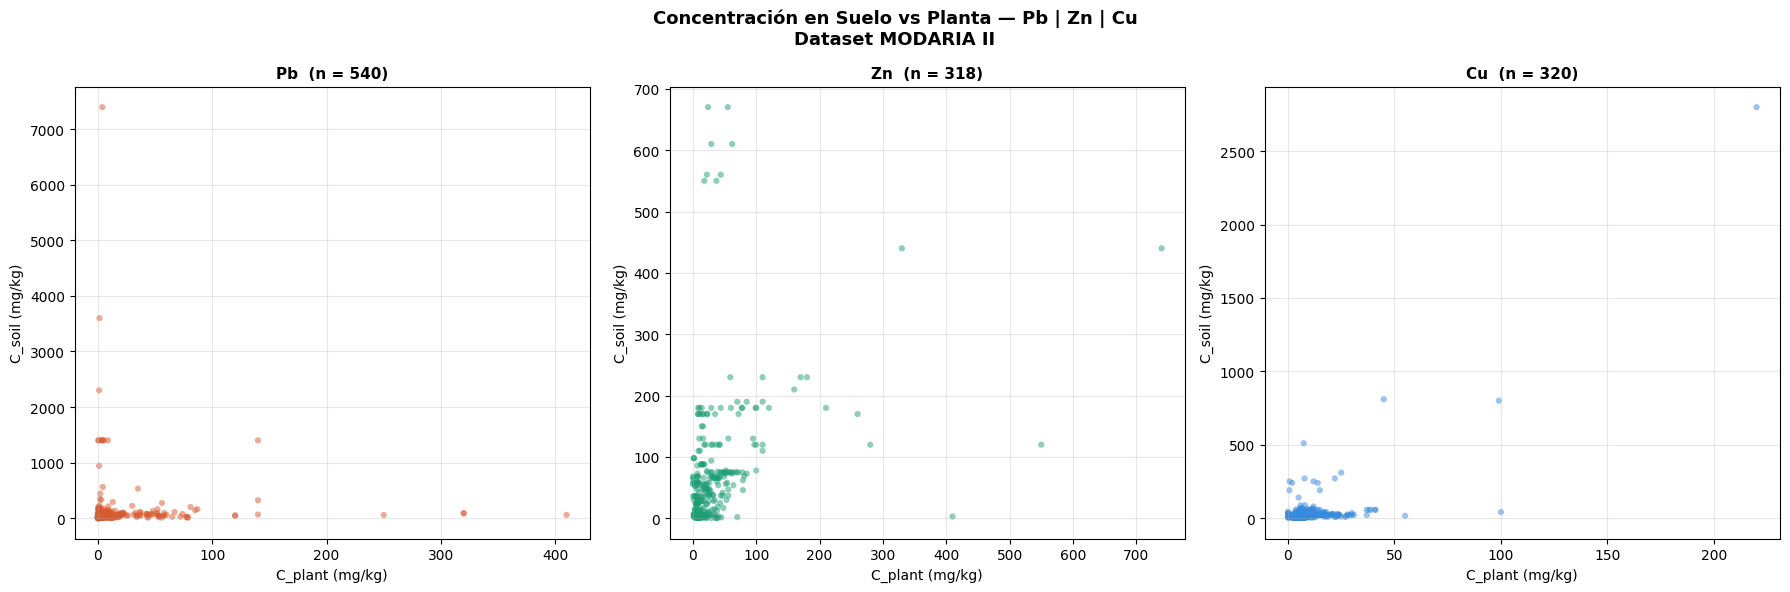

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar_columna(df, col):
    nueva = df[col].astype(str).str.replace('<', '', regex=False)
    return pd.to_numeric(nueva, errors='coerce')

df['C_soil_limpia']  = limpiar_columna(df, 'C_soil')
df['C_plant_limpia'] = limpiar_columna(df, 'C_plant')

# Filtrar los tres elementos
elementos = {'Pb': '#D85A30', 'Zn': '#1D9E75', 'Cu': '#378ADD'}

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Concentración en Suelo vs Planta — Pb | Zn | Cu\nDataset MODARIA II',
    fontsize=13, fontweight='bold'
)

for ax, (elemento, color) in zip(axs, elementos.items()):
    datos = df[df['Element'] == elemento][['C_soil_limpia', 'C_plant_limpia']].dropna()

    ax.scatter(datos['C_plant_limpia'], datos['C_soil_limpia'],
               color=color, alpha=0.5, s=20, edgecolors='none')

    ax.set_xlabel('C_plant (mg/kg)', fontsize=10)
    ax.set_ylabel('C_soil (mg/kg)', fontsize=10)
    ax.set_title(f'{elemento}  (n = {len(datos)})', fontsize=11, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scatter_Pb_Zn_Cu.png', dpi=150, bbox_inches='tight')
plt.show()


Los tres elementos presentan patrones similares en la transferencia suelo-planta:

- **Pb:** la mayoría de puntos está concentrada cerca del origen
  con outliers de suelo muy alto (hasta 7,400 mg/kg) pero planta
  cercana a cero, evidenciando baja biodisponibilidad del plomo.
- **Zn:** mayor dispersión en ambos ejes con puntos de C_plant
  hasta 730 mg/kg, reflejando que el zinc se absorbe activamente
  por ser un micronutriente esencial.
- **Cu:** con concentraciones de suelo hasta
  2,500 mg/kg con transferencia moderada a planta.

Los tres elementos exhiben un patrón similar: la mayoría de las observaciones se concentran en la zona de bajas concentraciones (cerca del origen), mientras que unos pocos sitios con niveles extremos de contaminación crean valores atípicos que ocultan el comportamiento típico de la mayoría. Este fenómeno, típico en datos ambientales de metales pesados, refleja la heterogeneidad de los sitios de muestreo: la mayoría son suelos con contaminación de fondo natural, y solo unos pocos corresponden a áreas industriales o mineras con concentraciones muy altas.

En el Pb, por ejemplo, un outlier de 7,400 mg/kg distorsiona el eje Y, haciendo que más de 500 puntos por debajo de 200 mg/kg queden comprimidos en el 3% inferior del gráfico. Esto significa que el 93% de la información útil se enmascara debido a un solo punto extremo. Lo mismo sucede en Zn, donde un outlier de 670 mg/kg oculta la densidad de datos entre 0-100, y en Cu, con un outlier de 2,500 mg/kg que comprime la mayoría de los datos.

Esto tiene una implicación directa para la pregunta de investigación:
**si se analiza la transferencia del suelo a la planta sin escalar, se estaría
modelando el comportamiento de los sitios extremos y no el de la mayoría de las plantas tropicales**.

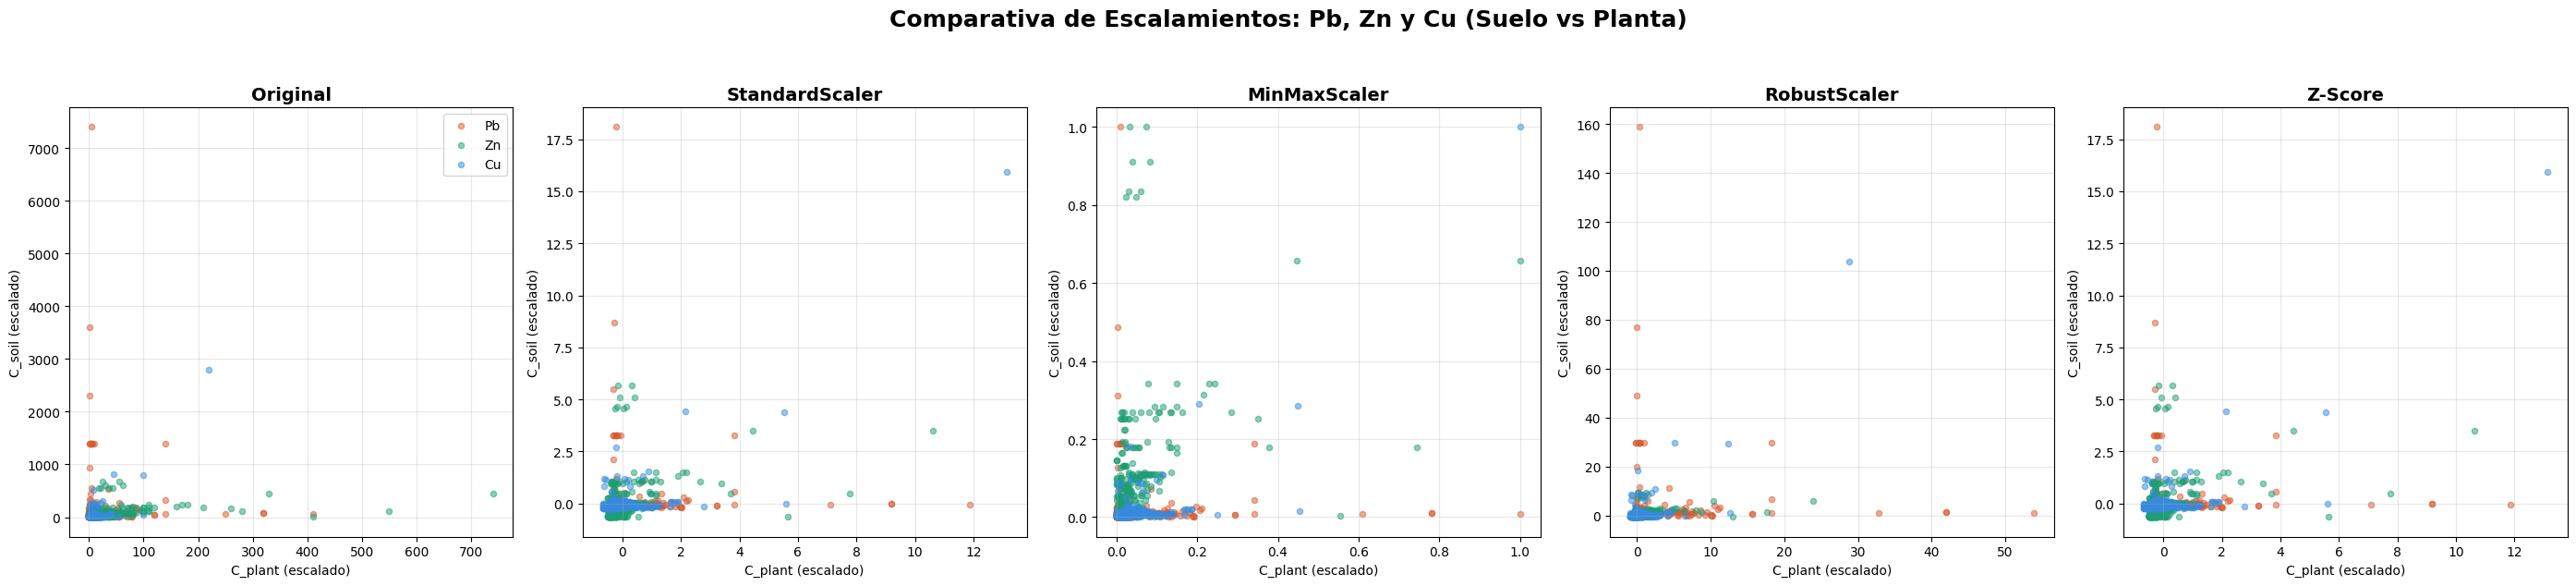

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
from scipy.stats import zscore

# 1. Preparación de datos para los tres elementos
elementos_config = {
    'Pb': '#D85A30',
    'Zn': '#1D9E75',
    'Cu': '#378ADD'
}

# Creamos un diccionario para guardar los datos limpios de cada elemento
datos_dict = {}
for el in elementos_config.keys():
    df_el = df[df['Element'] == el][['C_plant_limpia', 'C_soil_limpia']].dropna()
    datos_dict[el] = df_el.values

# 2. Definición de la función para aplicar y graficar
def graficar_escalamientos(datos_dict, config):
    fig, axs = plt.subplots(1, 5, figsize=(28, 6))
    fig.suptitle('Comparativa de Escalamientos: Pb, Zn y Cu (Suelo vs Planta)',
                 fontsize=18, fontweight='bold', y=1.05)

    nombres_metodos = ['Original', 'StandardScaler', 'MinMaxScaler', 'RobustScaler', 'Z-Score']

    for i, nombre in enumerate(nombres_metodos):
        for el, color in config.items():
            X = datos_dict[el]

            # Aplicar el escalamiento según el índice de la columna (Subplot)
            if nombre == 'Original':
                data_plot = X
            elif nombre == 'StandardScaler':
                data_plot = StandardScaler().fit_transform(X)
            elif nombre == 'MinMaxScaler':
                data_plot = MinMaxScaler().fit_transform(X)
            elif nombre == 'RobustScaler':
                data_plot = RobustScaler().fit_transform(X)
            elif nombre == 'Z-Score':
                data_plot = zscore(X)

            axs[i].scatter(data_plot[:, 0], data_plot[:, 1],
                           color=color, alpha=0.5, s=20, label=el if i == 0 else "")

        axs[i].set_title(nombre, fontweight='bold', fontsize=14)
        axs[i].set_xlabel('C_plant (escalado)')
        axs[i].set_ylabel('C_soil (escalado)')
        axs[i].grid(True, alpha=0.3)
        if i == 0: axs[i].legend()

    plt.tight_layout()
    plt.show()

# Ejecutar la gráfica
graficar_escalamientos(datos_dict, elementos_config)

### Análisis comparativo de métodos de escalamiento

En los datos originales las escalas son incomparables entre Pb
(0–7,400 mg/kg), Zn (0–670 mg/kg) y Cu (0–2,500 mg/kg), haciendo
imposible cualquier comparación visual directa entre elementos.

El **StandardScaler y Z-Score** producen resultados matemáticos idénticos: ambos ajustan la escala, pero los outliers extremos de Pb, lo que comprime la concentración central de datos y desplaza la mediana a valores negativos en los tres elementos.

El **MinMaxScaler** ajusta todos los valores dentro del rango [0,1], pero el outlier máximo de Pb domina la escala, lo que provoca que Cu y Zn queden comprimidos en franjas muy estrechas y se pierda resolución en el núcleo de datos.

El **RobustScaler** es el método más adecuado para este conjunto de datos porque, al utilizar la mediana y el IQR como referencia, mantiene la estructura interna de cada elemento. Sin embargo , la visualización es difícil debido a los outliers.

Shape original: (7151, 41)

Registros tras filtrar Pb, Zn, Cu: 219

Registros por elemento:
Element
Pb    120
Zn     50
Cu     49
Name: count, dtype: int64

Estadísticas descriptivas por elemento (C_soil):
         count    mean     std  min    25%   50%     75%     max
Element                                                         
Cu        49.0   27.56   17.64  3.1  17.00  26.0   34.00    88.0
Pb       120.0  129.84  342.12  1.7  10.75  45.0   64.25  1400.0
Zn        50.0   96.77   97.33  5.0  28.50  47.0  170.00   440.0


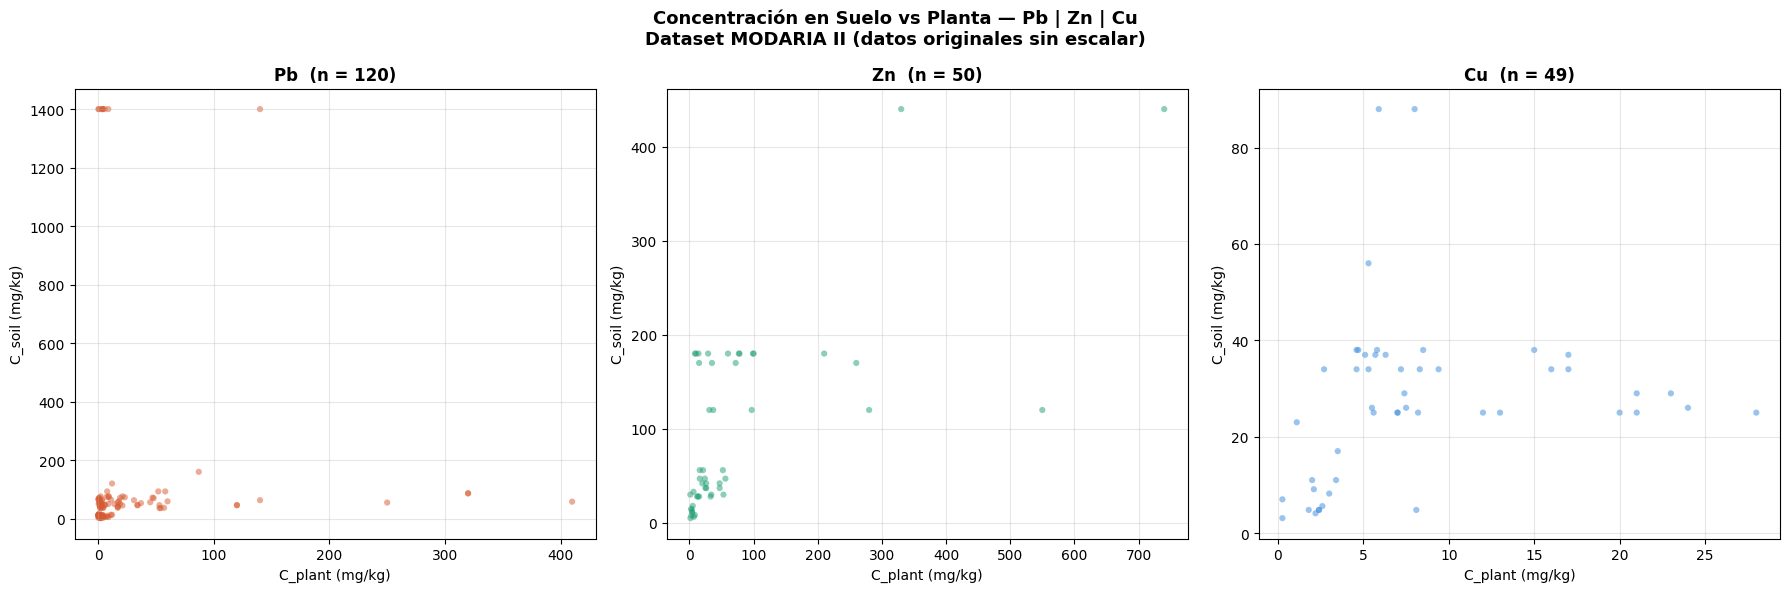

✅ Gráfico 1 guardado: scatter original

✅ Escalamiento aplicado correctamente.


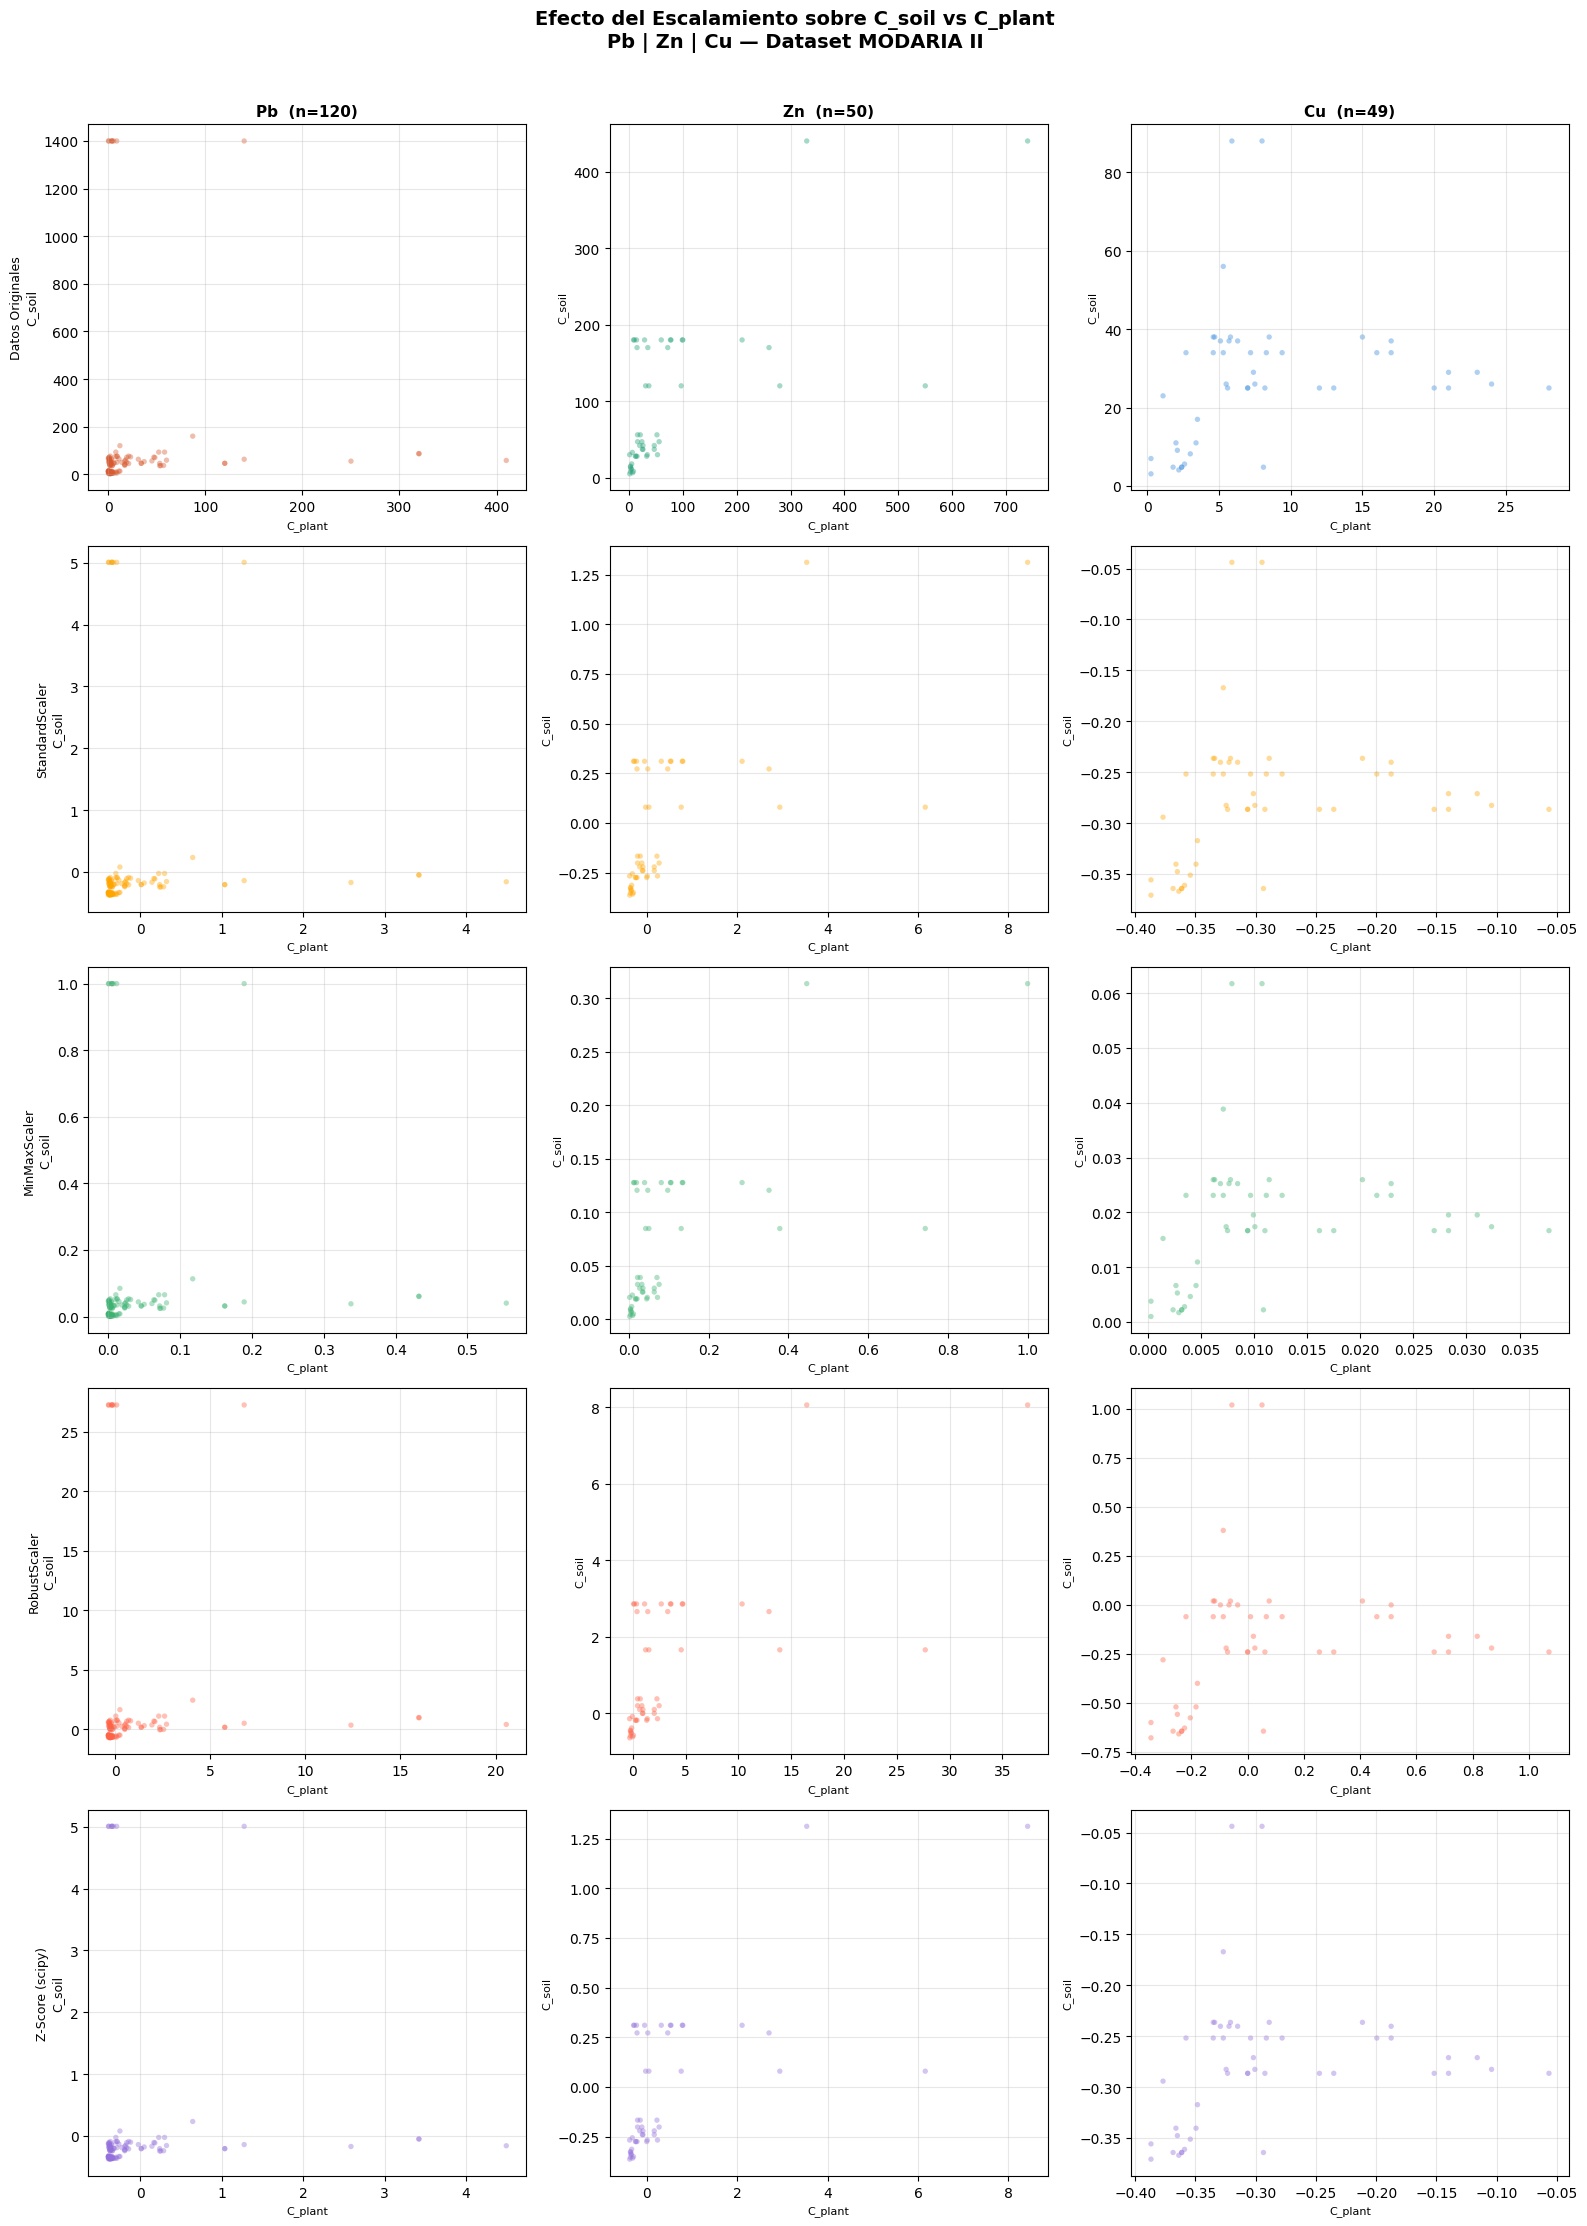

✅ Gráfico 2 guardado: scatter comparativo escalado

TABLA RESUMEN — C_soil por elemento y método de escalamiento
Elemento         Método    Media  Mediana     Mín       Máx
      Pb       Original 129.8408  45.0000  1.7000 1400.0000
      Pb StandardScaler   0.1172  -0.2095 -0.3762    5.0078
      Pb   MinMaxScaler   0.0916   0.0310  0.0000    1.0000
      Pb   RobustScaler   1.8568   0.1600 -0.7060   27.2600
      Pb        Z-Score   0.1172  -0.2095 -0.3762    5.0078
      Zn       Original  96.7660  47.0000  5.0000  440.0000
      Zn StandardScaler  -0.0102  -0.2018 -0.3635    1.3114
      Zn   MinMaxScaler   0.0680   0.0324  0.0024    0.3135
      Zn   RobustScaler   1.1953   0.2000 -0.6400    8.0600
      Zn        Z-Score  -0.0102  -0.2018 -0.3635    1.3114
      Cu       Original  27.5571  26.0000  3.1000   88.0000
      Cu StandardScaler  -0.2766  -0.2826 -0.3708   -0.0439
      Cu   MinMaxScaler   0.0185   0.0174  0.0010    0.0617
      Cu   RobustScaler  -0.1889  -0.2200 -0.67

In [ ]:
# ============================================================
# EJERCICIO 1: ESCALAMIENTO DE VARIABLES CONTINUAS
# Dataset: IAEA MODARIA II Tropical
# Elementos seleccionados: Pb, Zn, Cu (metales pesados)
# Justificación: rangos similares de concentración en suelo
# (17-38 mg/kg mediana), relevantes para transferencia suelo-planta
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

# ============================================================
# 1. CARGA DEL DATASET
# ============================================================

url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

print("Shape original:", df.shape)

# ============================================================
# 2. LIMPIEZA Y FILTRADO POR ELEMENTOS
# ============================================================

def limpiar_columna(df, col):
    """Quita el símbolo '<' de límites de detección y convierte a numérico."""
    nueva = df[col].astype(str).str.replace('<', '', regex=False)
    return pd.to_numeric(nueva, errors='coerce')

df['C_soil_limpia']  = limpiar_columna(df, 'C_soil')
df['C_plant_limpia'] = limpiar_columna(df, 'C_plant')
df['CR_limpia']      = limpiar_columna(df, 'CR')

# Filtrar por los tres elementos seleccionados
elementos   = ['Pb', 'Zn', 'Cu']
colores_elem = {'Pb': '#D85A30', 'Zn': '#1D9E75', 'Cu': '#378ADD'}

df_filtrado = df[df['Element'].isin(elementos)].copy()
df_filtrado = df_filtrado[['Element', 'C_soil_limpia', 'C_plant_limpia', 'CR_limpia']].dropna()

print(f"\nRegistros tras filtrar Pb, Zn, Cu: {len(df_filtrado)}")
print("\nRegistros por elemento:")
print(df_filtrado['Element'].value_counts())
print("\nEstadísticas descriptivas por elemento (C_soil):")
print(df_filtrado.groupby('Element')['C_soil_limpia'].describe().round(2))

# ============================================================
# 3. GRÁFICA 1 — SCATTER: C_plant (eje X) vs C_soil (eje Y)
#    Un panel por elemento, misma escala de referencia
#    Muestra la relación entre concentración en suelo y planta
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle(
    'Concentración en Suelo vs Planta — Pb | Zn | Cu\n'
    'Dataset MODARIA II (datos originales sin escalar)',
    fontsize=13, fontweight='bold'
)

for ax, elemento in zip(axs, elementos):
    datos = df_filtrado[df_filtrado['Element'] == elemento]
    color = colores_elem[elemento]

    ax.scatter(datos['C_plant_limpia'], datos['C_soil_limpia'],
               color=color, alpha=0.5, s=20, edgecolors='none')

    ax.set_xlabel('C_plant (mg/kg)', fontsize=10)
    ax.set_ylabel('C_soil (mg/kg)', fontsize=10)
    ax.set_title(f'{elemento}  (n = {len(datos)})', fontsize=12, fontweight='bold')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ejercicio1_scatter_original.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 1 guardado: scatter original")

# ============================================================
# 4. APLICACIÓN DE LOS CUATRO MÉTODOS DE ESCALAMIENTO
#    Se escalan C_soil y C_plant juntas para preservar
#    la relación entre ambas variables
# ============================================================

variables     = ['C_soil_limpia', 'C_plant_limpia']
df_vals       = df_filtrado[variables].copy()

# --- StandardScaler ---
scaler_std    = StandardScaler()
df_std        = pd.DataFrame(scaler_std.fit_transform(df_vals),
                              columns=[f'{v}_std' for v in variables])

# --- MinMaxScaler ---
scaler_minmax = MinMaxScaler()
df_minmax     = pd.DataFrame(scaler_minmax.fit_transform(df_vals),
                              columns=[f'{v}_minmax' for v in variables])

# --- RobustScaler ---
scaler_robust = RobustScaler()
df_robust     = pd.DataFrame(scaler_robust.fit_transform(df_vals),
                              columns=[f'{v}_robust' for v in variables])

# --- Z-Score (scipy) ---
df_zscore     = pd.DataFrame(stats.zscore(df_vals, axis=0),
                              columns=[f'{v}_zscore' for v in variables])

# Agregar columna de elemento a cada DataFrame escalado
for d in [df_std, df_minmax, df_robust, df_zscore]:
    d['Element'] = df_filtrado['Element'].values

print("\n✅ Escalamiento aplicado correctamente.")

# ============================================================
# 5. GRÁFICA 2 — SCATTER COMPARATIVO: original vs 4 escaladores
#    Filas = métodos (5), Columnas = elementos (3)
#    Se mantiene C_plant en eje X y C_soil en eje Y
# ============================================================

metodos = [
    (df_filtrado, 'C_soil_limpia',  'C_plant_limpia',  'Datos Originales',  'gray'),
    (df_std,      'C_soil_limpia_std',   'C_plant_limpia_std',   'StandardScaler',    'orange'),
    (df_minmax,   'C_soil_limpia_minmax','C_plant_limpia_minmax','MinMaxScaler',       'mediumseagreen'),
    (df_robust,   'C_soil_limpia_robust','C_plant_limpia_robust','RobustScaler',       'tomato'),
    (df_zscore,   'C_soil_limpia_zscore','C_plant_limpia_zscore','Z-Score (scipy)',    'mediumpurple'),
]

fig, axs = plt.subplots(5, 3, figsize=(16, 22))
fig.suptitle(
    'Efecto del Escalamiento sobre C_soil vs C_plant\n'
    'Pb | Zn | Cu — Dataset MODARIA II',
    fontsize=14, fontweight='bold', y=1.01
)

for fila, (datos_df, col_y, col_x, titulo_metodo, color_metodo) in enumerate(metodos):
    for col, elemento in enumerate(elementos):
        ax  = axs[fila, col]
        sub = datos_df[datos_df['Element'] == elemento]
        color = colores_elem[elemento] if fila == 0 else color_metodo

        ax.scatter(sub[col_x], sub[col_y],
                   color=color, alpha=0.4, s=15, edgecolors='none')

        # Título de columna solo en primera fila
        if fila == 0:
            ax.set_title(f'{elemento}  (n={len(sub)})',
                         fontsize=11, fontweight='bold')

        # Título de método solo en primera columna
        if col == 0:
            ax.set_ylabel(f'{titulo_metodo}\nC_soil', fontsize=9)
        else:
            ax.set_ylabel('C_soil', fontsize=8)

        ax.set_xlabel('C_plant', fontsize=8)
        ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ejercicio1_scatter_escalado.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 guardado: scatter comparativo escalado")

# ============================================================
# 6. TABLA RESUMEN — estadísticas de C_soil por elemento y método
# ============================================================

print("\n" + "="*65)
print("TABLA RESUMEN — C_soil por elemento y método de escalamiento")
print("="*65)

filas = []
for elemento in elementos:
    orig = df_filtrado[df_filtrado['Element'] == elemento]['C_soil_limpia']
    std  = df_std[df_std['Element']    == elemento]['C_soil_limpia_std']
    mm   = df_minmax[df_minmax['Element'] == elemento]['C_soil_limpia_minmax']
    rob  = df_robust[df_robust['Element'] == elemento]['C_soil_limpia_robust']
    zsc  = df_zscore[df_zscore['Element'] == elemento]['C_soil_limpia_zscore']

    for nombre, serie in [('Original', orig), ('StandardScaler', std),
                           ('MinMaxScaler', mm), ('RobustScaler', rob),
                           ('Z-Score', zsc)]:
        filas.append({
            'Elemento': elemento,
            'Método':   nombre,
            'Media':    round(float(serie.mean()), 4),
            'Mediana':  round(float(serie.median()), 4),
            'Mín':      round(float(serie.min()), 4),
            'Máx':      round(float(serie.max()), 4),
        })

resumen = pd.DataFrame(filas)
print(resumen.to_string(index=False))

### Análisis comparativo de métodos de escalamiento
Para evidenciar mejor el comportamiento de las concentraciones, se graficaron las dispersiones y los escalamientos de cada uno de los elementos por aparte.

En los datos originales, las medianas de C_soil son similares para Pb (45.00), Zn (47.00) y Cu (26.00) mg/kg. Sin embargo, las medias difieren: Pb: 129.84, Zn: 96.77, Cu: 27.56, lo que sugiere que Pb y Zn tienen valores extremos que elevan notablemente la media comparada con la mediana. Por otro lado, Cu presenta una distribución más equilibrada, con una media y mediana muy similares (27.56 frente a 26.00).

El **StandardScaler y Z-Score** producen resultados matemáticamente iguales para los tres elementos, como lo indican los valores en la tabla. Esto hace que la mediana esté en valores negativos para todos ellos (Pb: -0.21, Zn: -0.20, Cu: -0.28). Esto indica que más de la mitad de los datos de cada elemento están por debajo de cero, una distorsión causada por el desplazamiento hacia arriba de la media global del conjunto Pb+Zn+Cu, debido a los valores extremos de Pb.

El **MinMaxScaler** ajusta todos los valores al rango [0,1], pero presenta un problema en Cu: su valor máximo escalado es solo 0.0617, mientras que el de Pb llega a 1.0. Esto hace que Cu quede comprimido en menos del 7% del rango, perdiendo resolución para concentraciones más bajas.

El **RobustScaler** es el único método que logra medianas cercanas a cero, reflejando de manera coherente el comportamiento real de cada elemento — Pb: 0.16, Zn: 0.20, Cu: -0.22 — y colocando correctamente el núcleo de los datos.
La mediana de Cu es negativa (-0.22) porque su distribución es más simétrica en torno a su centro. Esto es común con RobustScaler cuando los datos no presentan un sesgo fuerte. Lo importante es que todas las medianas están próximas a cero, lo que indica que el escalador preservó la estructura auténtica de cada metal sin distorsionar la distribución general.

Para el análisis de transferencia suelo-planta de metales pesados en
plantas tropicales el **RobustScaler es el método más recomendable**:
preserva la estructura interna de cada elemento, permite identificar
los outliers de Pb (máx = 27.26) y Zn (máx = 8.06) como sitios de
alta contaminación real sin que distorsionen la escala del núcleo de
datos, y mantiene visible el patrón diferencial de acumulación entre
los tres metales.

## <span style="color:#2F749F;"><strong>Ejercicio 2: Comparación de escalamiento RobustScaler vs Z-Score</strong></span>

A partir de un conjunto de datos real, analiza cómo cambia la escala de las variables al aplicar **estandarización con Z-Score** y **escalamiento robusto**, y compara visualmente sus efectos cuando existen **posibles valores atípicos**.

1. Aplica los siguientes métodos de escalamiento sobre las variables seleccionadas:
   - **StandardScaler** (Z-Score).
   - **RobustScaler** (basado en mediana e IQR).

2. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución **escalada con Z-Score**
   - Distribución **escalada con RobustScaler**

3. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

Registros tras filtrar Pb, Zn, Cu: 1178

Registros por elemento:
Element
Cu    320
Pb    540
Zn    318
Name: count, dtype: int64

ESTADÍSTICAS DESCRIPTIVAS DE C_soil POR ELEMENTO (datos originales)
         count   mean     std  min   25%   50%    75%     max
Element                                                      
Cu       320.0  43.39  173.50  0.4  7.22  20.0  34.00  2800.0
Pb       540.0  85.80  404.76  0.4  7.75  17.0  54.25  7400.0
Zn       318.0  70.13  105.81  0.5  7.00  38.5  75.00   670.0
✅ Escalamiento completado correctamente.

TABLA RESUMEN — C_soil POR ELEMENTO Y MÉTODO DE ESCALAMIENTO
Elemento   Método                    Media    Mediana        Std        Mín        Máx
----------------------------------------------------------------------------------------------------
Pb         Original                  85.80      17.00     404.76       0.40    7400.00
           Z-Score                 -0.0000    -0.1701     1.0009    -0.2112    18.0871
           RobustScaler    

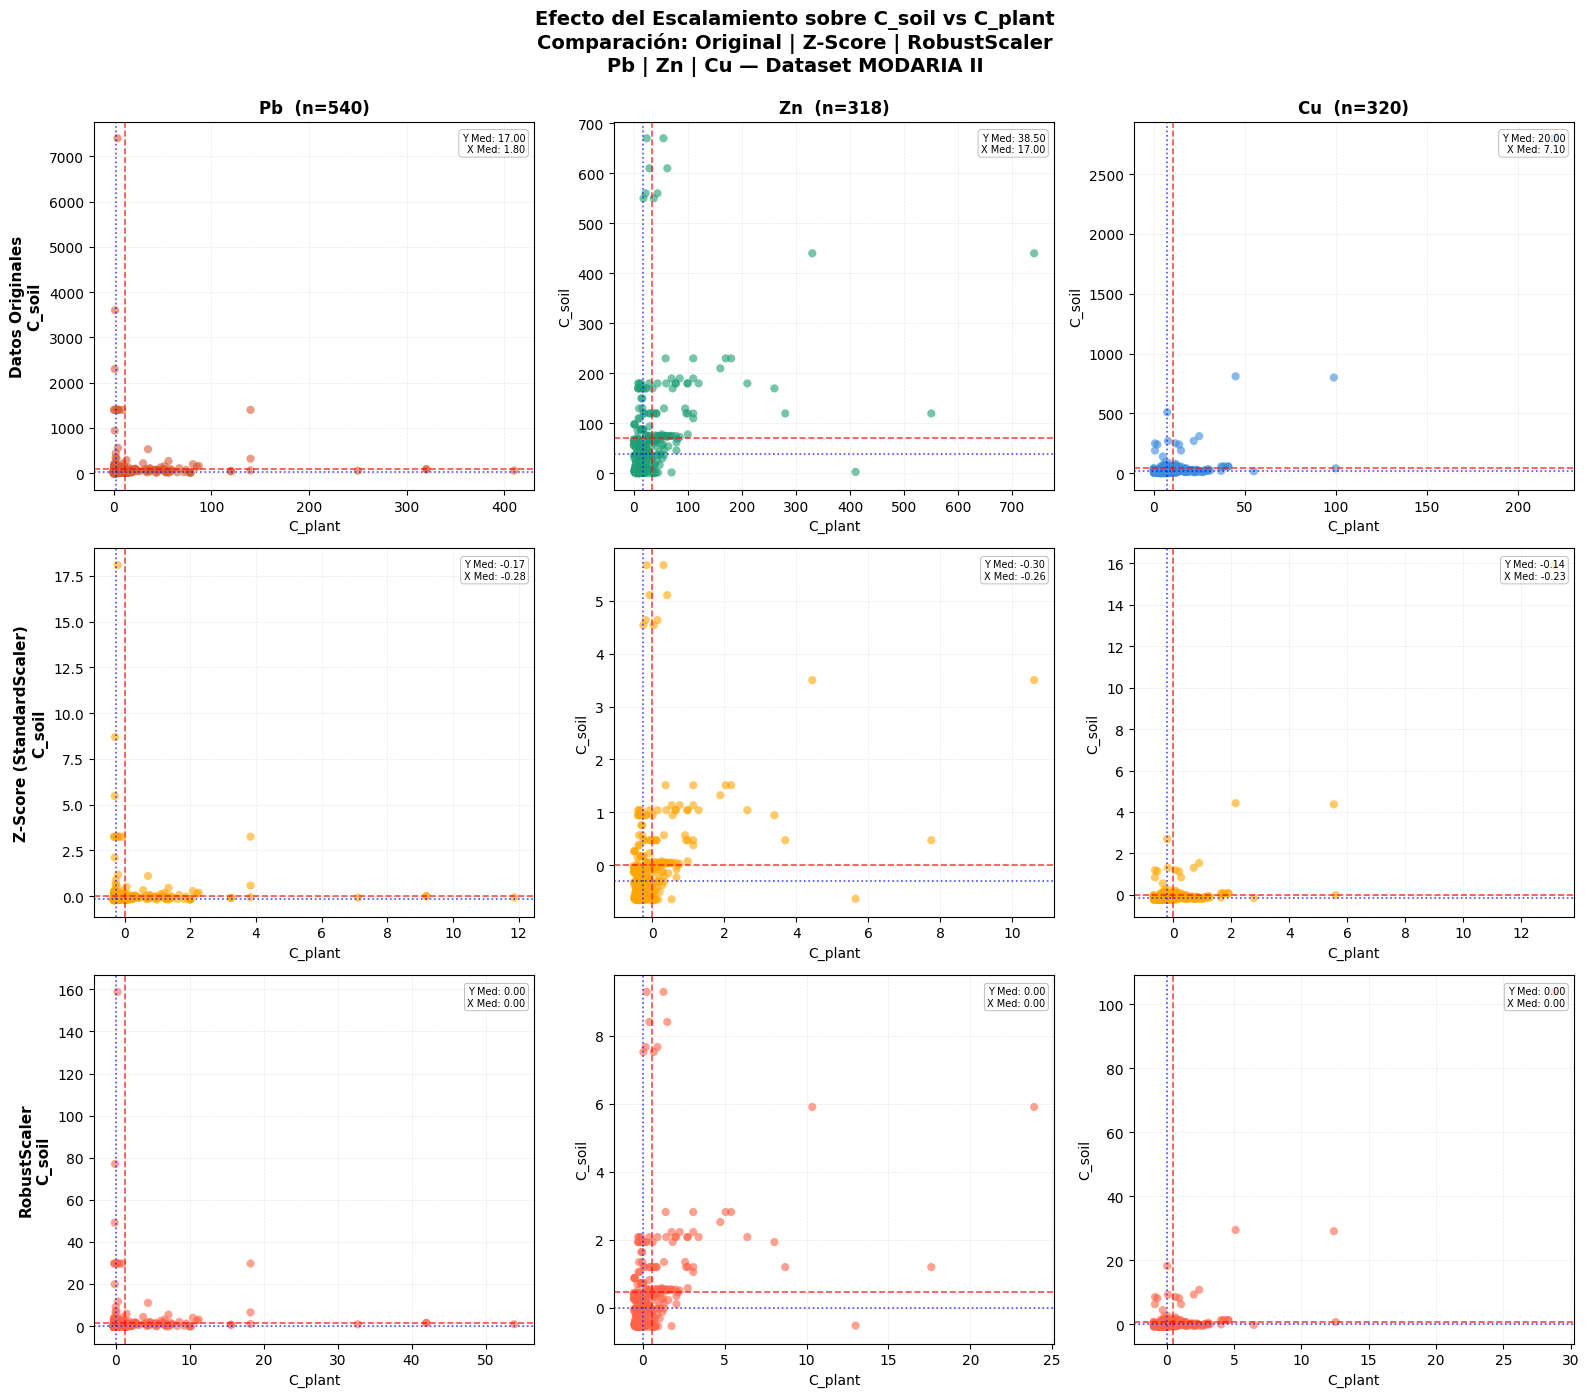

In [14]:
# ============================================================
# EJERCICIO 2: COMPARACIÓN Z-SCORE vs ROBUSTSCALER
# Dataset: IAEA MODARIA II Tropical
# Elementos: Pb, Zn, Cu (metales pesados)
# SOLO gráficos de dispersión (C_soil vs C_plant)
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, RobustScaler

# ============================================================
# 1. CARGA Y LIMPIEZA DEL DATASET
# ============================================================

url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar_columna(df, col):
    """Quita el símbolo '<' de límites de detección y convierte a numérico."""
    nueva = df[col].astype(str).str.replace('<', '', regex=False)
    return pd.to_numeric(nueva, errors='coerce')

df['C_soil_limpia']  = limpiar_columna(df, 'C_soil')
df['C_plant_limpia'] = limpiar_columna(df, 'C_plant')

elementos = ['Pb', 'Zn', 'Cu']
colores_elem = {'Pb': '#D85A30', 'Zn': '#1D9E75', 'Cu': '#378ADD'}

df_filtrado = df[df['Element'].isin(elementos)].copy()
df_filtrado = df_filtrado[['Element', 'C_soil_limpia', 'C_plant_limpia']].dropna()

print(f"Registros tras filtrar Pb, Zn, Cu: {len(df_filtrado)}")
print("\nRegistros por elemento:")
print(df_filtrado['Element'].value_counts().sort_index())

print("\n" + "="*80)
print("ESTADÍSTICAS DESCRIPTIVAS DE C_soil POR ELEMENTO (datos originales)")
print("="*80)
print(df_filtrado.groupby('Element')['C_soil_limpia'].describe().round(2))

# ============================================================
# 2. APLICACIÓN DE ESCALADORES POR ELEMENTO (SEPARADO)
# ============================================================

df_zscore_list = []
df_robust_list = []

for elemento in elementos:
    subset = df_filtrado[df_filtrado['Element'] == elemento].copy()
    datos_element = subset[['C_soil_limpia', 'C_plant_limpia']].values

    # Z-Score
    scaler_z = StandardScaler()
    datos_z = scaler_z.fit_transform(datos_element)

    # RobustScaler
    scaler_robust = RobustScaler()
    datos_robust = scaler_robust.fit_transform(datos_element)

    df_z_temp = pd.DataFrame(datos_z, columns=['C_soil_z', 'C_plant_z'], index=subset.index)
    df_z_temp['Element'] = elemento
    df_zscore_list.append(df_z_temp)

    df_rob_temp = pd.DataFrame(datos_robust, columns=['C_soil_rob', 'C_plant_rob'], index=subset.index)
    df_rob_temp['Element'] = elemento
    df_robust_list.append(df_rob_temp)

df_zscore = pd.concat(df_zscore_list, ignore_index=True)
df_robust = pd.concat(df_robust_list, ignore_index=True)

print("✅ Escalamiento completado correctamente.\n")

# ============================================================
# 3. TABLA RESUMEN
# ============================================================

print("="*100)
print("TABLA RESUMEN — C_soil POR ELEMENTO Y MÉTODO DE ESCALAMIENTO")
print("="*100)
print(f"{'Elemento':<10} {'Método':<20} {'Media':>10} {'Mediana':>10} {'Std':>10} {'Mín':>10} {'Máx':>10}")
print("-"*100)

for elemento in elementos:
    orig = df_filtrado[df_filtrado['Element'] == elemento]['C_soil_limpia']
    z    = df_zscore[df_zscore['Element'] == elemento]['C_soil_z']
    rob  = df_robust[df_robust['Element'] == elemento]['C_soil_rob']

    print(f"{elemento:<10} {'Original':<20} {orig.mean():>10.2f} {orig.median():>10.2f} "
          f"{orig.std():>10.2f} {orig.min():>10.2f} {orig.max():>10.2f}")
    print(f"{'':<10} {'Z-Score':<20} {z.mean():>10.4f} {z.median():>10.4f} "
          f"{z.std():>10.4f} {z.min():>10.4f} {z.max():>10.4f}")
    print(f"{'':<10} {'RobustScaler':<20} {rob.mean():>10.4f} {rob.median():>10.4f} "
          f"{rob.std():>10.4f} {rob.min():>10.4f} {rob.max():>10.4f}")
    print()

# ============================================================
# 4. GRÁFICA ÚNICA - SCATTER: Original vs Z-Score vs RobustScaler
#    Matriz 3 filas x 3 columnas
#    Filas = métodos | Columnas = elementos
# ============================================================

metodos_scatter = [
    (df_filtrado, 'C_soil_limpia',  'C_plant_limpia',  'Datos Originales',           'gray'),
    (df_zscore,   'C_soil_z',       'C_plant_z',       'Z-Score (StandardScaler)',   'orange'),
    (df_robust,   'C_soil_rob',     'C_plant_rob',     'RobustScaler',               'tomato'),
]

fig, axs = plt.subplots(3, 3, figsize=(16, 14))
fig.suptitle(
    'Efecto del Escalamiento sobre C_soil vs C_plant\n'
    'Comparación: Original | Z-Score | RobustScaler\n'
    'Pb | Zn | Cu — Dataset MODARIA II',
    fontsize=14, fontweight='bold', y=0.995
)

for fila, (datos_df, col_y, col_x, titulo_metodo, color_metodo) in enumerate(metodos_scatter):
    for col, elemento in enumerate(elementos):
        ax = axs[fila, col]
        sub = datos_df[datos_df['Element'] == elemento]

        color_punto = colores_elem[elemento] if fila == 0 else color_metodo

        ax.scatter(sub[col_x], sub[col_y],
                   color=color_punto, alpha=0.6, s=35, edgecolors='none')

        # Líneas de referencia: media y mediana en AMBOS ejes
        # Eje Y (C_soil)
        media_y = sub[col_y].mean()
        mediana_y = sub[col_y].median()
        ax.axhline(media_y, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axhline(mediana_y, color='blue', linestyle=':', linewidth=1.2, alpha=0.7)

        # Eje X (C_plant)
        media_x = sub[col_x].mean()
        mediana_x = sub[col_x].median()
        ax.axvline(media_x, color='red', linestyle='--', linewidth=1.2, alpha=0.7)
        ax.axvline(mediana_x, color='blue', linestyle=':', linewidth=1.2, alpha=0.7)

        # Leyenda compacta en la esquina
        ax.text(0.98, 0.97, f'Y Med: {mediana_y:.2f}\nX Med: {mediana_x:.2f}',
                transform=ax.transAxes, fontsize=7, verticalalignment='top', horizontalalignment='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.7, edgecolor='gray', linewidth=0.5))

        # Título de columna (elemento)
        if fila == 0:
            n = len(sub)
            ax.set_title(f'{elemento}  (n={n})',
                         fontsize=12, fontweight='bold')

        # Etiqueta de eje Y (método)
        if col == 0:
            ax.set_ylabel(f'{titulo_metodo}\nC_soil', fontsize=11, fontweight='bold')
        else:
            ax.set_ylabel('C_soil', fontsize=10)

        ax.set_xlabel('C_plant', fontsize=10)
        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

plt.tight_layout()
plt.savefig('ejercicio2_scatter_comparison.png', dpi=150, bbox_inches='tight')
plt.show()



El Z-Score desplaza las medianas a -0.17 Pb, -0.30 Zn y -0.14 Cu, lo que en presencia de outliers extremos crea un punto de referencia poco significativo: la media se desplaza hacia arriba por valores atípicos, haciendo que valores típicos (17, 38.5 y 20 mg/kg) queden por debajo de cero en la escala escalada. Por otro lado, RobustScaler centra la mediana mediante el IQR, un método más resistente que ajusta el valor típico real (17, 38.5, 20 mg/kg) exactamente en 0.0, permitiendo que los outliers extremos sigan siendo visibles y claramente identificables como contaminación. Para análisis de transferencia suelo-planta, RobustScaler es más recomendable porque su referencia (la mediana) es resistente a outliers y más significativa: refleja el centro típico de los datos, no un valor sesgado por extremos.


## <span style="color:#2F749F;"><strong>Ejercicio 3: Comparación de normalización L1 y L2</strong></span>

A partir de un conjunto de datos real, analiza cómo cambian los valores de las variables al aplicar **normalización L1 y L2**, y compara visualmente sus efectos sobre la distribución de los datos.

1. Selecciona al menos **tres variables numéricas** para el análisis
2. Aplica los siguientes métodos de **normalización** sobre las variables seleccionadas utilizando `Normalizer` de `sklearn.preprocessing`:
   - **Normalización L1**
   - **Normalización L2**

3. Genera **gráficas comparativas** que permitan visualizar la distribución de al menos **una de las variables seleccionadas** en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **normalización L1**
   - Distribución con **normalización L2**

4. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

Registros disponibles: 1877
Forma del array: (1877, 3)  →  1877 observaciones × 3 variables

Estadísticas descriptivas (datos originales):
       C_soil_limpia  C_plant_limpia  CR_limpia
count       1877.000        1877.000   1877.000
mean         685.559        2357.889      3.205
std         3975.833       14398.500     12.745
min            0.100           0.009      0.001
25%           19.000           1.600      0.077
50%           51.000           9.700      0.290
75%          180.000         120.000      0.980
max        40000.000      230000.000    250.000

Verificación L1 — norma promedio por fila: 1.0000 (debe ser 1.0)
Verificación L2 — norma promedio por fila: 1.0000 (debe ser 1.0)

✅ Normalización aplicada correctamente.


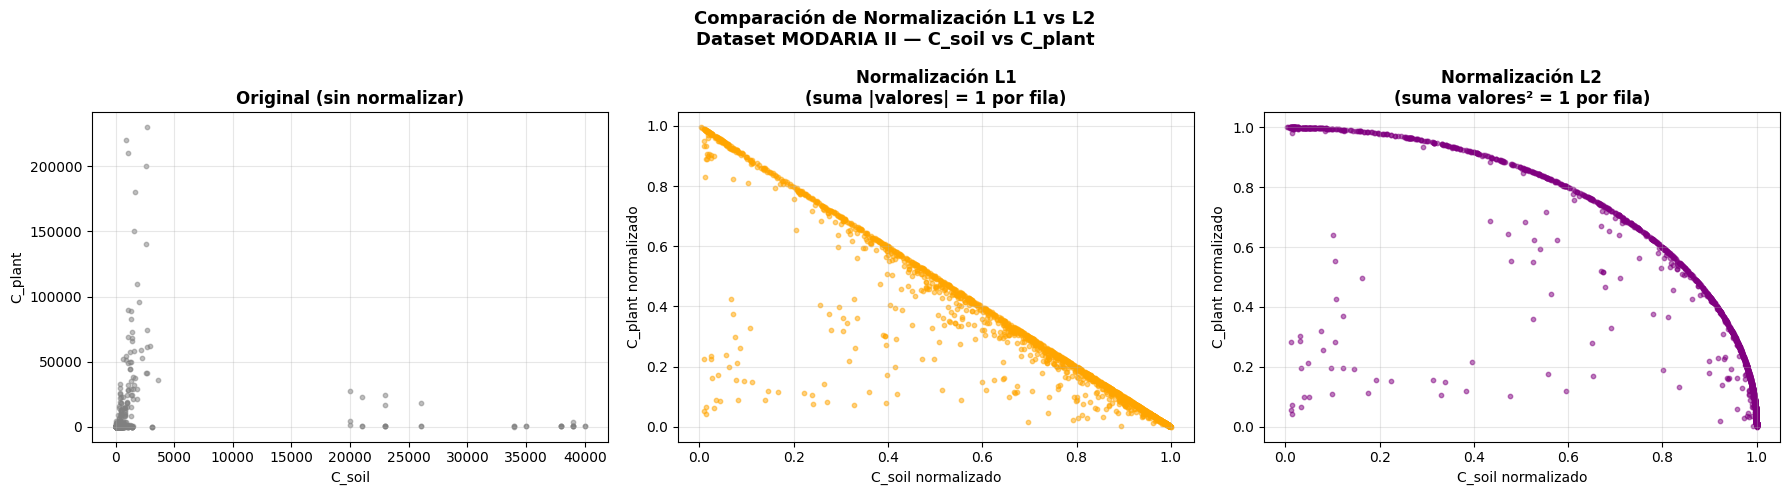

✅ Gráfico 1 guardado: ejercicio3_scatter2D_L1_vs_L2.png


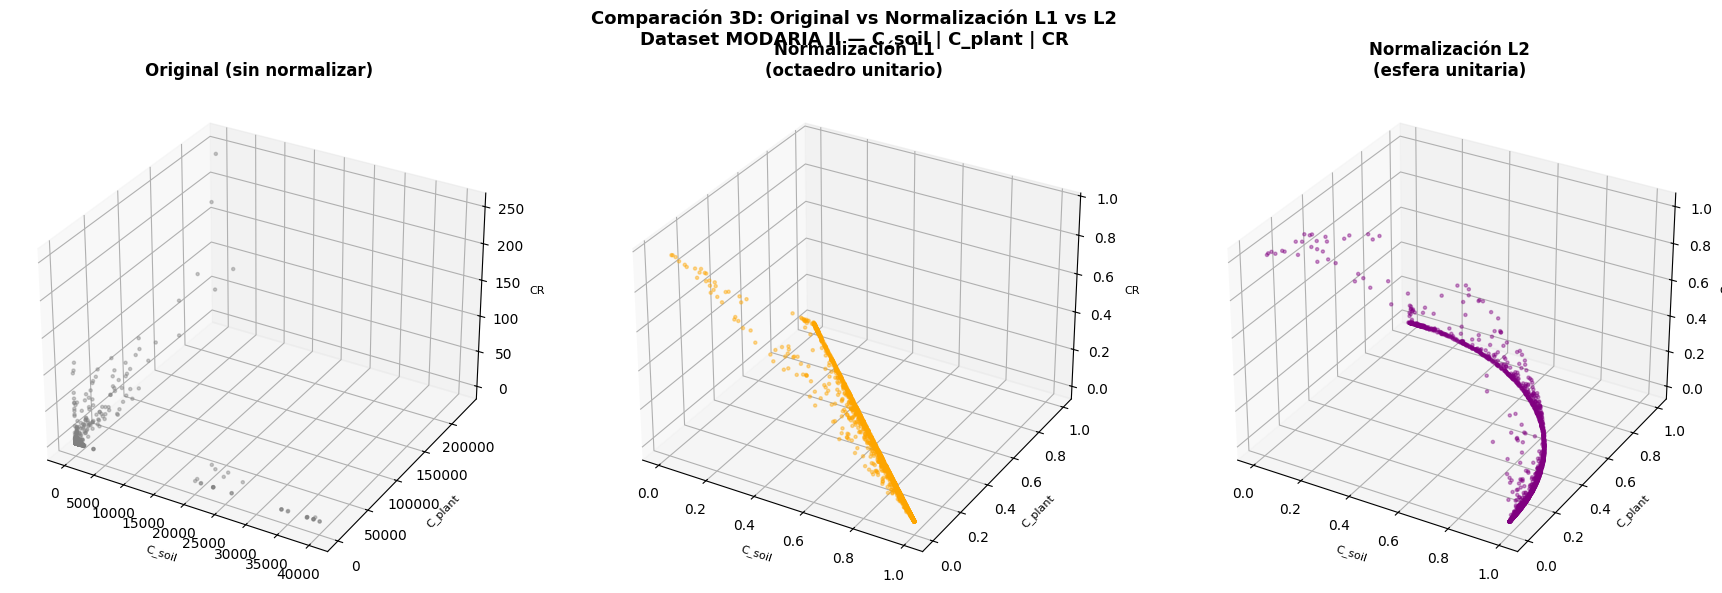

✅ Gráfico 2 guardado: ejercicio3_scatter3D_L1_vs_L2.png


In [5]:
# ============================================================
# EJERCICIO 3: NORMALIZACIÓN L1 vs L2
# Dataset: IAEA MODARIA II Tropical
# Variables: C_soil, C_plant, CR
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import Normalizer
from mpl_toolkits.mplot3d import Axes3D

# ============================================================
# 1. CARGA Y LIMPIEZA
# ============================================================

url = 'https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/iaea-modaria-ii-tropical-dataset.csv'
df = pd.read_csv(url)

def limpiar_columna(df, col):
    nueva = df[col].astype(str).str.replace('<', '', regex=False)
    return pd.to_numeric(nueva, errors='coerce')

df['C_soil_limpia']  = limpiar_columna(df, 'C_soil')
df['C_plant_limpia'] = limpiar_columna(df, 'C_plant')
df['CR_limpia']      = limpiar_columna(df, 'CR')

variables  = ['C_soil_limpia', 'C_plant_limpia', 'CR_limpia']
etiquetas  = ['C_soil', 'C_plant', 'CR']
df_clean   = df[variables].dropna().copy()

# Convertir a array numpy
X = df_clean.values

print(f"Registros disponibles: {len(X)}")
print(f"Forma del array: {X.shape}  →  {X.shape[0]} observaciones × {X.shape[1]} variables")
print("\nEstadísticas descriptivas (datos originales):")
print(df_clean.describe().round(3))

# ============================================================
# 2. APLICACIÓN DE NORMALIZACIÓN L1 y L2
#    Normalizer actúa por FILA
# ============================================================

# Normalización L1 (norma Manhattan: suma de |valores| = 1)
normalizador_l1 = Normalizer(norm='l1')
X_l1 = normalizador_l1.fit_transform(X)

# Normalización L2 (norma Euclidiana: suma de valores² = 1)
normalizador_l2 = Normalizer(norm='l2')
X_l2 = normalizador_l2.fit_transform(X)

# Verificación: comprobar que las normas son efectivamente 1
norma_l1 = np.sum(np.abs(X_l1), axis=1)
norma_l2 = np.sqrt(np.sum(X_l2**2, axis=1))
print(f"\nVerificación L1 — norma promedio por fila: {norma_l1.mean():.4f} (debe ser 1.0)")
print(f"Verificación L2 — norma promedio por fila: {norma_l2.mean():.4f} (debe ser 1.0)")

print("\n✅ Normalización aplicada correctamente.")

# ============================================================
# 3. GRÁFICAS COMPARATIVAS 2D (scatter)
#    Ejes: C_soil (x) vs C_plant (y)
#    Se muestran los 3 escenarios: original, L1, L2
# ============================================================

fig, axs = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(
    'Comparación de Normalización L1 vs L2\n'
    'Dataset MODARIA II — C_soil vs C_plant',
    fontsize=13, fontweight='bold'
)

# Original
axs[0].scatter(X[:, 0], X[:, 1], color='gray', alpha=0.5, s=10)
axs[0].set_title('Original (sin normalizar)', fontweight='bold')
axs[0].set_xlabel('C_soil')
axs[0].set_ylabel('C_plant')
axs[0].grid(True, alpha=0.3)

# L1
axs[1].scatter(X_l1[:, 0], X_l1[:, 1], color='orange', alpha=0.5, s=10)
axs[1].set_title('Normalización L1\n(suma |valores| = 1 por fila)', fontweight='bold')
axs[1].set_xlabel('C_soil normalizado')
axs[1].set_ylabel('C_plant normalizado')
axs[1].grid(True, alpha=0.3)

# L2
axs[2].scatter(X_l2[:, 0], X_l2[:, 1], color='purple', alpha=0.5, s=10)
axs[2].set_title('Normalización L2\n(suma valores² = 1 por fila)', fontweight='bold')
axs[2].set_xlabel('C_soil normalizado')
axs[2].set_ylabel('C_plant normalizado')
axs[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ejercicio3_scatter2D_L1_vs_L2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 1 guardado: ejercicio3_scatter2D_L1_vs_L2.png")

# ============================================================
# 4. GRÁFICAS 3D (las tres variables)
#    Ejes: C_soil, C_plant, CR
# ============================================================

fig = plt.figure(figsize=(18, 6))
fig.suptitle(
    'Comparación 3D: Original vs Normalización L1 vs L2\n'
    'Dataset MODARIA II — C_soil | C_plant | CR',
    fontsize=13, fontweight='bold'
)

# Original 3D
ax1 = fig.add_subplot(131, projection='3d')
ax1.scatter(X[:, 0], X[:, 1], X[:, 2], color='gray', alpha=0.4, s=5)
ax1.set_title('Original (sin normalizar)', fontweight='bold')
ax1.set_xlabel('C_soil', fontsize=8)
ax1.set_ylabel('C_plant', fontsize=8)
ax1.set_zlabel('CR', fontsize=8)

# L1 3D
ax2 = fig.add_subplot(132, projection='3d')
ax2.scatter(X_l1[:, 0], X_l1[:, 1], X_l1[:, 2], color='orange', alpha=0.4, s=5)
ax2.set_title('Normalización L1\n(octaedro unitario)', fontweight='bold')
ax2.set_xlabel('C_soil', fontsize=8)
ax2.set_ylabel('C_plant', fontsize=8)
ax2.set_zlabel('CR', fontsize=8)

# L2 3D
ax3 = fig.add_subplot(133, projection='3d')
ax3.scatter(X_l2[:, 0], X_l2[:, 1], X_l2[:, 2], color='purple', alpha=0.4, s=5)
ax3.set_title('Normalización L2\n(esfera unitaria)', fontweight='bold')
ax3.set_xlabel('C_soil', fontsize=8)
ax3.set_ylabel('C_plant', fontsize=8)
ax3.set_zlabel('CR', fontsize=8)

plt.tight_layout()
plt.savefig('ejercicio3_scatter3D_L1_vs_L2.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Gráfico 2 guardado: ejercicio3_scatter3D_L1_vs_L2.png")

En la gráfica original (gris), resulta difícil analizar los datos porque el 99% de las muestras están agrupadas muy cerca del cero. Esto se debe a la presencia de valores extremos (outliers) que distorsionan los ejes, ocultando la verdadera relación entre el suelo y la planta en niveles normales de radiación.

Al aplicar la Normalización L1 (amarilla), los datos quedan ordenados en una línea. Es esencial notar que todos los puntos se sitúan dentro de un triángulo limitado por la diagonal que conecta el 1 en $X$ con el 1 en $Y$. Esto visualmente nos muestra que si un punto está más cerca del eje horizontal, indica una mayor predominancia del suelo en la muestra; si se acerca al eje vertical, significa que la planta ha acumulado más metal. La dispersión por debajo de la línea amarilla revela que la relación entre suelo y planta no es constante, sino que varía según la muestra, permitiendo comparar sitios muy contaminados con sitios limpios en una misma escala de 0 a 1.
La normalización L2 distribuye los datos en una curvatura uniforme, igualando la magnitud de todas las observaciones y facilitando la detección de patrones de absorción sin que los valores atípicos distorsionen los resultados. Sin embargo, para este estudio, yo utilizaria la normalización L1, ya que su estructura lineal es más fácil de entender y comparar qué porcentaje de contaminación total queda en el suelo y cuál pasa a la planta. Esto simplifica la interpretación de la transferencia de metales pesados en ecosistemas tropicales.

## <span style="color:#2F749F;"><strong>Ejercicio 4: Comparación de transformaciones para reducir asimetría</strong></span>

4. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Transformación logarítmica** usando `np.log()` o `np.log1p()`
   - **Transformación logarítmica reflejada** (útil cuando existe asimetría negativa)
   - **Transformación cuadrática** usando `x²`
   - **Transformación Box-Cox** usando `scipy.stats.boxcox`

5. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación log**
   - Distribución con **log reflejado**
   - Distribución con **transformación cuadrática**
   - Distribución con **transformación Box-Cox**

6. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

=== Ejercicio 4 · Pb ===
Transformación  Skewness  Curtosis
      Original   13.0074  209.1142
   Logarítmica    0.2981    0.6346
 Log Reflejada  -22.7757  522.3964
    Cuadrática   21.0691  463.6377
       Box-Cox   -0.0080    0.2280


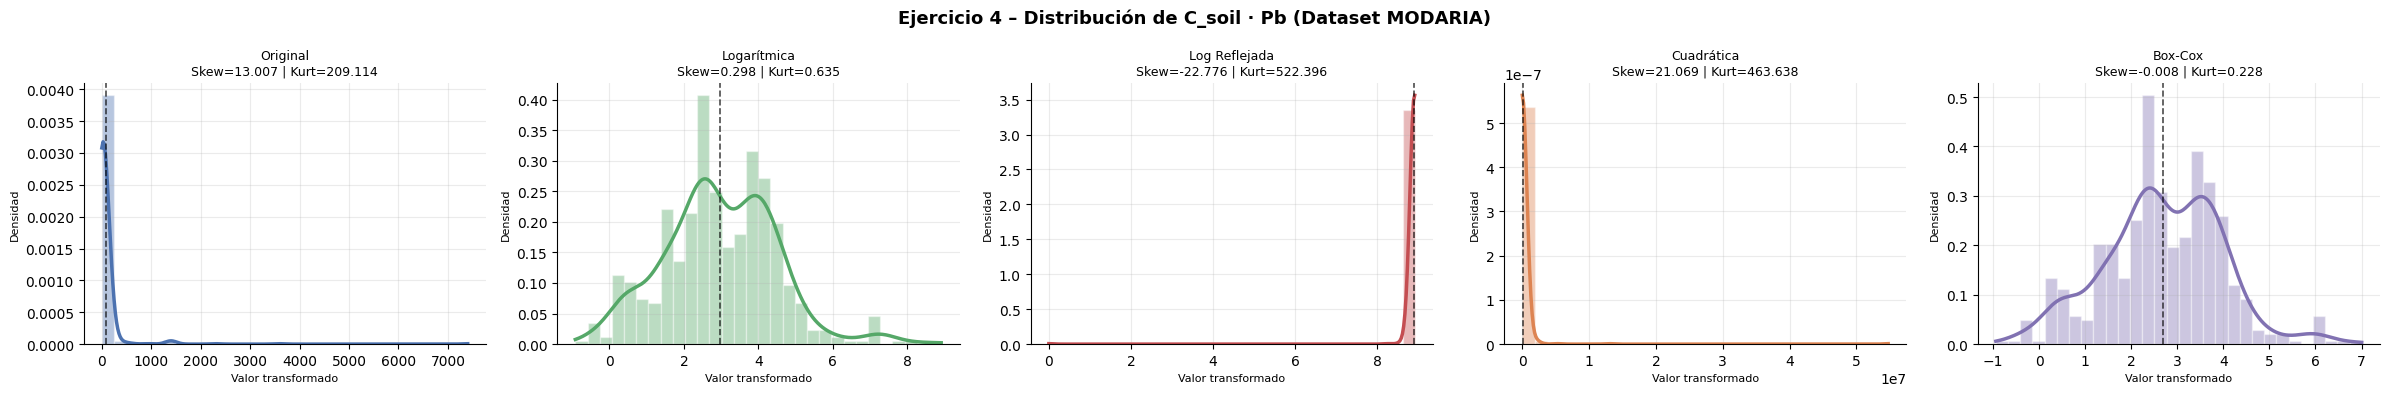

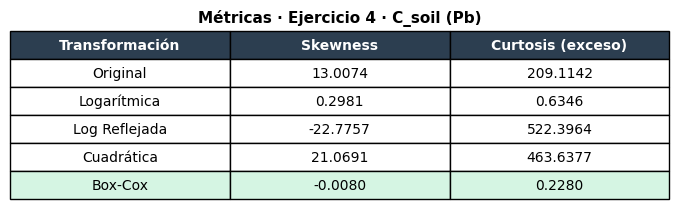

✓ Pb – Ejercicio 4 guardado.

=== Ejercicio 4 · Zn ===
Transformación  Skewness  Curtosis
      Original    3.5307   14.5754
   Logarítmica   -0.5602   -0.3842
 Log Reflejada   -8.8482   88.9596
    Cuadrática    5.6247   32.2148
       Box-Cox   -0.0516   -0.4798


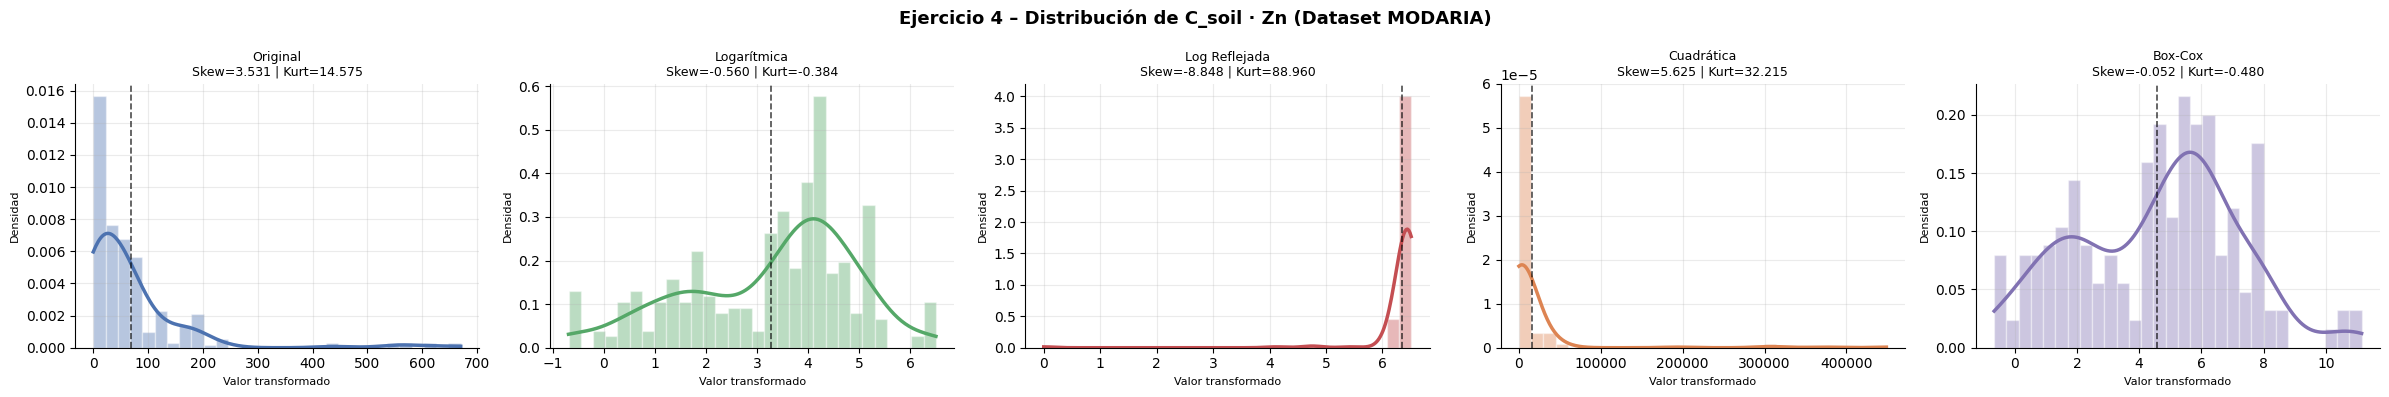

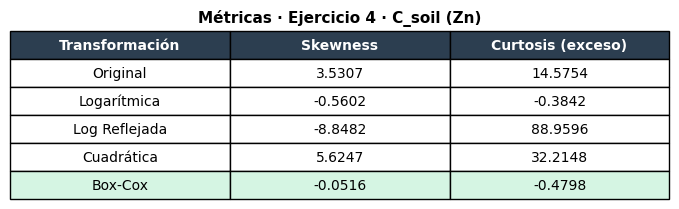

✓ Zn – Ejercicio 4 guardado.

=== Ejercicio 4 · Cu ===
Transformación  Skewness  Curtosis
      Original   13.2293  199.9382
   Logarítmica    0.1587    1.4094
 Log Reflejada  -17.6679  311.7054
    Cuadrática   17.4243  305.5911
       Box-Cox   -0.0141    1.1600


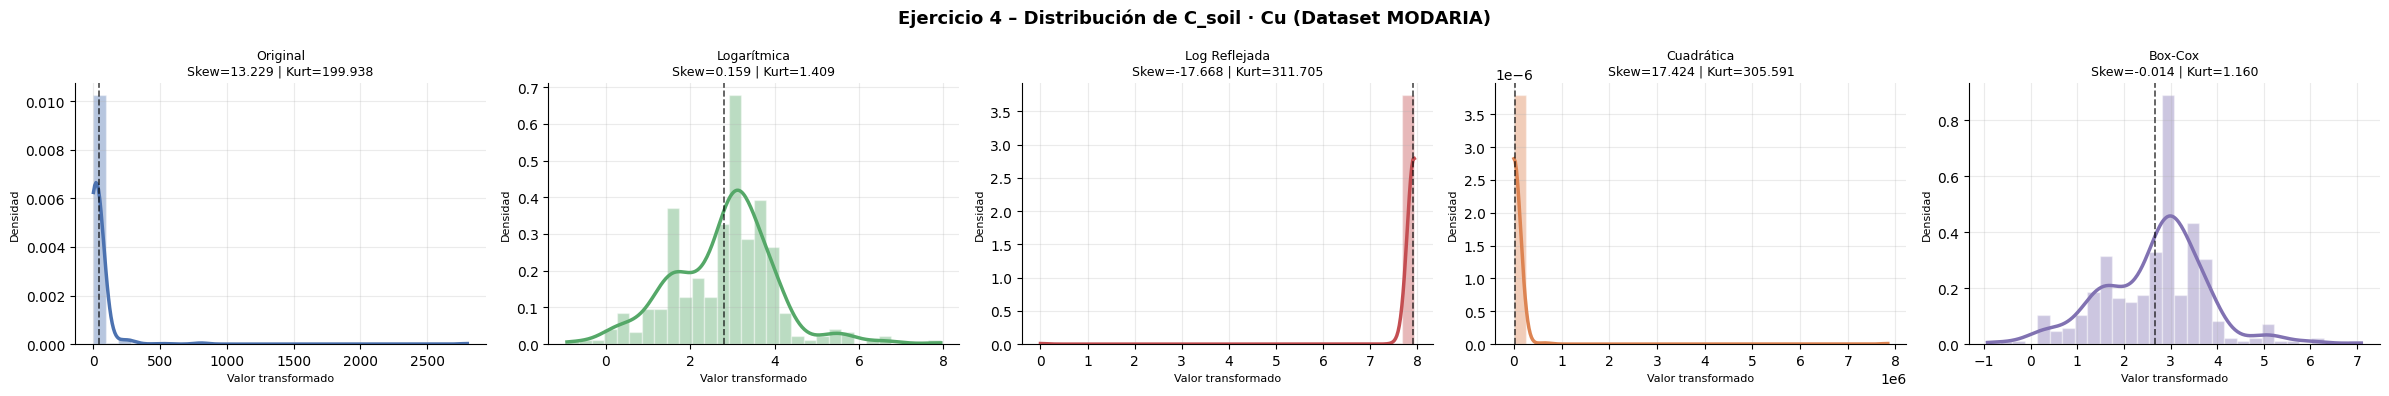

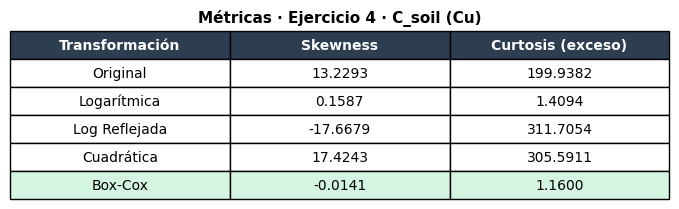

✓ Cu – Ejercicio 4 guardado.


In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ── Carga y limpieza ─────────────────────────────────────────────────────────
url = ('https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/'
       'resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/'
       'iaea-modaria-ii-tropical-dataset.csv')
df = pd.read_csv(url)

def limpiar(val):
    try: return float(str(val).replace('<', ''))
    except: return np.nan

df['C_soil_n']  = df['C_soil'].apply(limpiar)
df['C_plant_n'] = df['C_plant'].apply(limpiar)

colores = ['#4C72B0', '#55A868', '#C44E52', '#DD8452', '#8172B2']

# ════════════════════════════════════════════════════════════════════════════
# EJERCICIO 4 – Pb
# ════════════════════════════════════════════════════════════════════════════
df_pb = df[(df['Element'] == 'Pb') & (df['C_soil_n'] > 0) & (df['C_plant_n'] > 0)].copy()
x_pb  = df_pb['C_soil_n'].values

x_pb_log  = np.log(x_pb)
x_pb_ref  = np.log(np.max(x_pb) + 1 - x_pb)
x_pb_sq   = x_pb ** 2
x_pb_bc,_ = stats.boxcox(x_pb)

nombres = ['Original', 'Logarítmica', 'Log Reflejada', 'Cuadrática', 'Box-Cox']
datos   = [x_pb, x_pb_log, x_pb_ref, x_pb_sq, x_pb_bc]

metricas_pb = pd.DataFrame({
    'Transformación': nombres,
    'Skewness': [round(stats.skew(d),      4) for d in datos],
    'Curtosis':  [round(stats.kurtosis(d), 4) for d in datos],
})
print("=== Ejercicio 4 · Pb ===")
print(metricas_pb.to_string(index=False))

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
fig.suptitle('Ejercicio 4 – Distribución de C_soil · Pb (Dataset MODARIA)',
             fontsize=13, fontweight='bold')
for ax, d, nombre, color in zip(axes, datos, nombres, colores):
    ax.hist(d, bins=30, density=True, color=color, alpha=0.40, edgecolor='white')
    kde = stats.gaussian_kde(d)
    xs  = np.linspace(d.min(), d.max(), 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2.5)
    ax.axvline(np.mean(d), color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'{nombre}\nSkew={stats.skew(d):.3f} | Kurt={stats.kurtosis(d):.3f}', fontsize=9)
    ax.set_xlabel('Valor transformado', fontsize=8)
    ax.set_ylabel('Densidad', fontsize=8)
    ax.grid(True, alpha=0.25)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ejercicio4_Pb.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 2.2))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[r['Transformación'], f"{r['Skewness']:.4f}", f"{r['Curtosis']:.4f}"] for _, r in metricas_pb.iterrows()],
    colLabels=['Transformación', 'Skewness', 'Curtosis (exceso)'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1.3, 1.8)
for j in range(3):
    tabla[(0,j)].set_facecolor('#2C3E50')
    tabla[(0,j)].set_text_props(color='white', fontweight='bold')
min_idx = metricas_pb['Skewness'].abs().idxmin() + 1
for j in range(3): tabla[(min_idx,j)].set_facecolor('#D5F5E3')
ax2.set_title('Métricas · Ejercicio 4 · C_soil (Pb)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ejercicio4_Pb_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Pb – Ejercicio 4 guardado.")


# ════════════════════════════════════════════════════════════════════════════
# EJERCICIO 4 – Zn
# ════════════════════════════════════════════════════════════════════════════
df_zn = df[(df['Element'] == 'Zn') & (df['C_soil_n'] > 0) & (df['C_plant_n'] > 0)].copy()
x_zn  = df_zn['C_soil_n'].values

x_zn_log  = np.log(x_zn)
x_zn_ref  = np.log(np.max(x_zn) + 1 - x_zn)
x_zn_sq   = x_zn ** 2
x_zn_bc,_ = stats.boxcox(x_zn)

datos_zn = [x_zn, x_zn_log, x_zn_ref, x_zn_sq, x_zn_bc]

metricas_zn = pd.DataFrame({
    'Transformación': nombres,
    'Skewness': [round(stats.skew(d),      4) for d in datos_zn],
    'Curtosis':  [round(stats.kurtosis(d), 4) for d in datos_zn],
})
print("\n=== Ejercicio 4 · Zn ===")
print(metricas_zn.to_string(index=False))

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
fig.suptitle('Ejercicio 4 – Distribución de C_soil · Zn (Dataset MODARIA)',
             fontsize=13, fontweight='bold')
for ax, d, nombre, color in zip(axes, datos_zn, nombres, colores):
    ax.hist(d, bins=30, density=True, color=color, alpha=0.40, edgecolor='white')
    kde = stats.gaussian_kde(d)
    xs  = np.linspace(d.min(), d.max(), 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2.5)
    ax.axvline(np.mean(d), color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'{nombre}\nSkew={stats.skew(d):.3f} | Kurt={stats.kurtosis(d):.3f}', fontsize=9)
    ax.set_xlabel('Valor transformado', fontsize=8)
    ax.set_ylabel('Densidad', fontsize=8)
    ax.grid(True, alpha=0.25)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ejercicio4_Zn.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 2.2))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[r['Transformación'], f"{r['Skewness']:.4f}", f"{r['Curtosis']:.4f}"] for _, r in metricas_zn.iterrows()],
    colLabels=['Transformación', 'Skewness', 'Curtosis (exceso)'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1.3, 1.8)
for j in range(3):
    tabla[(0,j)].set_facecolor('#2C3E50')
    tabla[(0,j)].set_text_props(color='white', fontweight='bold')
min_idx = metricas_zn['Skewness'].abs().idxmin() + 1
for j in range(3): tabla[(min_idx,j)].set_facecolor('#D5F5E3')
ax2.set_title('Métricas · Ejercicio 4 · C_soil (Zn)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ejercicio4_Zn_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Zn – Ejercicio 4 guardado.")


# ════════════════════════════════════════════════════════════════════════════
# EJERCICIO 4 – Cu
# ════════════════════════════════════════════════════════════════════════════
df_cu = df[(df['Element'] == 'Cu') & (df['C_soil_n'] > 0) & (df['C_plant_n'] > 0)].copy()
x_cu  = df_cu['C_soil_n'].values

x_cu_log  = np.log(x_cu)
x_cu_ref  = np.log(np.max(x_cu) + 1 - x_cu)
x_cu_sq   = x_cu ** 2
x_cu_bc,_ = stats.boxcox(x_cu)

datos_cu = [x_cu, x_cu_log, x_cu_ref, x_cu_sq, x_cu_bc]

metricas_cu = pd.DataFrame({
    'Transformación': nombres,
    'Skewness': [round(stats.skew(d),      4) for d in datos_cu],
    'Curtosis':  [round(stats.kurtosis(d), 4) for d in datos_cu],
})
print("\n=== Ejercicio 4 · Cu ===")
print(metricas_cu.to_string(index=False))

fig, axes = plt.subplots(1, 5, figsize=(24, 4))
fig.suptitle('Ejercicio 4 – Distribución de C_soil · Cu (Dataset MODARIA)',
             fontsize=13, fontweight='bold')
for ax, d, nombre, color in zip(axes, datos_cu, nombres, colores):
    ax.hist(d, bins=30, density=True, color=color, alpha=0.40, edgecolor='white')
    kde = stats.gaussian_kde(d)
    xs  = np.linspace(d.min(), d.max(), 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2.5)
    ax.axvline(np.mean(d), color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'{nombre}\nSkew={stats.skew(d):.3f} | Kurt={stats.kurtosis(d):.3f}', fontsize=9)
    ax.set_xlabel('Valor transformado', fontsize=8)
    ax.set_ylabel('Densidad', fontsize=8)
    ax.grid(True, alpha=0.25)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ejercicio4_Cu.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 2.2))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[r['Transformación'], f"{r['Skewness']:.4f}", f"{r['Curtosis']:.4f}"] for _, r in metricas_cu.iterrows()],
    colLabels=['Transformación', 'Skewness', 'Curtosis (exceso)'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1.3, 1.8)
for j in range(3):
    tabla[(0,j)].set_facecolor('#2C3E50')
    tabla[(0,j)].set_text_props(color='white', fontweight='bold')
min_idx = metricas_cu['Skewness'].abs().idxmin() + 1
for j in range(3): tabla[(min_idx,j)].set_facecolor('#D5F5E3')
ax2.set_title('Métricas · Ejercicio 4 · C_soil (Cu)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ejercicio4_Cu_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Cu – Ejercicio 4 guardado.")

Los tres elementos muestran un patrón de dispersión caracterizado por distribuciones con una fuerte asimetría positiva, causada por una alta concentración de muestras en valores bajos de C_soil y la presencia de valores atípicos extremos.
Este fenómeno es típico en variables ambientales de contaminación, donde la mayoría de los suelos presentan concentraciones bajas y solo algunos sitios muestran niveles altamente contaminados.
La transformación log reflejada resulta inútil en los tres casos porque está diseñada para asimetría negativa, y la cuadrática empeora la simetria al amplificar los valores extremos. La transformación logarítmica es una solución práctica y simple que reduce significativamente la asimetría, siendo especialmente efectiva para Pb y Cu donde lleva el Skewness por debajo de 0.3. No obstante, Box-Cox supera a la logarítmica en los tres elementos al optimizar automáticamente el parámetro λ, logrando valores de Skewness prácticamente nulos, por lo que es la técnica más recomendable para variables ambientales con este perfil de distribución.

## <span style="color:#2F749F;"><strong>Ejercicio 5: Comparación de transformaciones para reducir asimetría</strong></span>

1. Selecciona al menos **dos variables numéricas** para el análisis (por ejemplo:  

2. Aplica las siguientes **transformaciones** sobre una de las variables seleccionadas:

   - **Raíz cuadrada** usando `np.sqrt()`  
   - **Recíproca** usando `1/x`  
   - **Transformación Yeo-Johnson** usando `PowerTransformer(method="yeo-johnson")`

3. Genera **gráficas comparativas** que permitan visualizar la distribución de la variable en los siguientes escenarios:
   - Distribución **original**
   - Distribución con **transformación raíz cuadrada**
   - Distribución con **transformación recíproca**
   - Distribución con **transformación Yeo-Johnson**

4. Escribe un análisis de **máximo cinco líneas** en el que expliques las diferencias entre las técnicas o métodos, su impacto en los resultados y cuál consideras más recomendable, justificando brevemente tu elección.

=== Ejercicio 5 · Pb ===
 Transformación  Skewness  Curtosis
       Original   13.0074  209.1142
  Raíz Cuadrada    5.5274   44.2018
Recíproca (1/x)    3.9737   22.0871
    Yeo-Johnson    0.0067   -0.1935


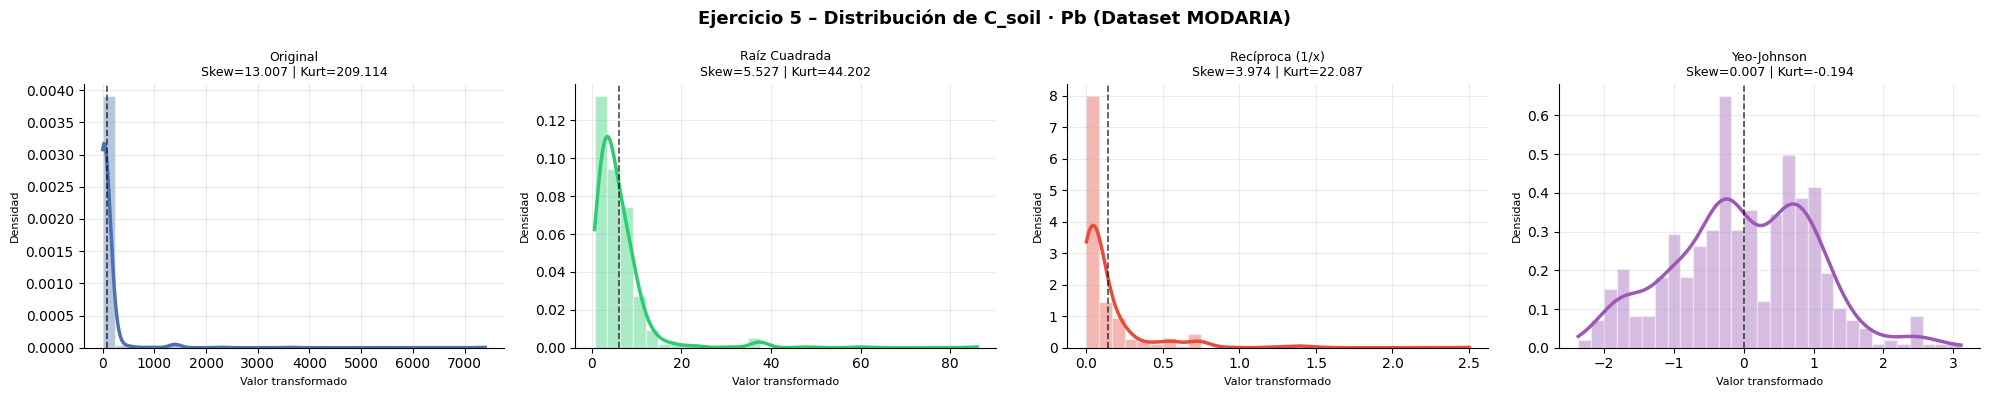

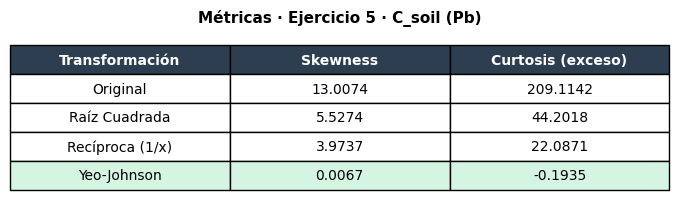

✓ Pb – Ejercicio 5 guardado.

=== Ejercicio 5 · Zn ===
 Transformación  Skewness  Curtosis
       Original    3.5307   14.5754
  Raíz Cuadrada    1.3444    2.7077
Recíproca (1/x)    3.8443   15.3137
    Yeo-Johnson   -0.0358   -0.6406


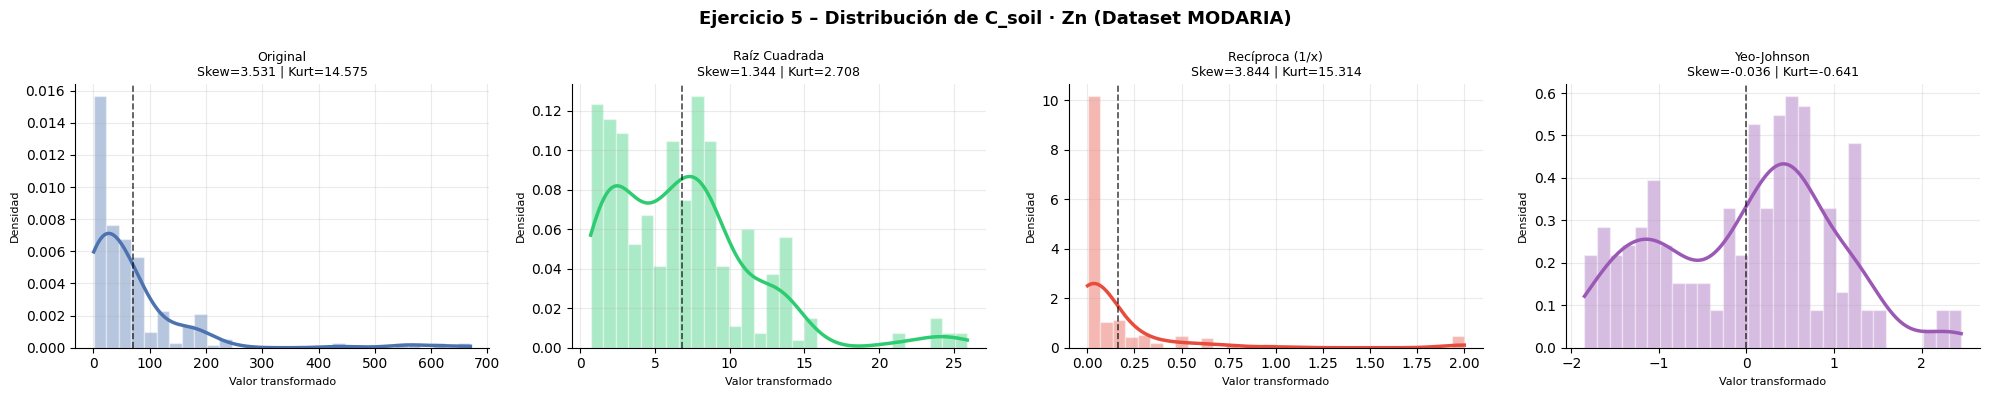

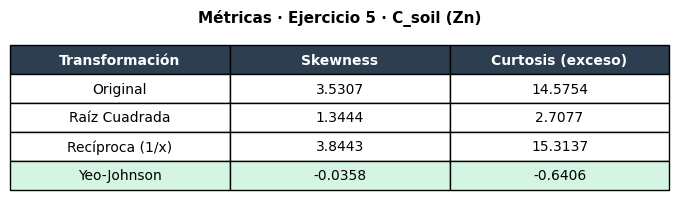

✓ Zn – Ejercicio 5 guardado.

=== Ejercicio 5 · Cu ===
 Transformación  Skewness  Curtosis
       Original   13.2293  199.9382
  Raíz Cuadrada    5.7971   51.1466
Recíproca (1/x)    5.5406   43.6456
    Yeo-Johnson   -0.0275    0.5242


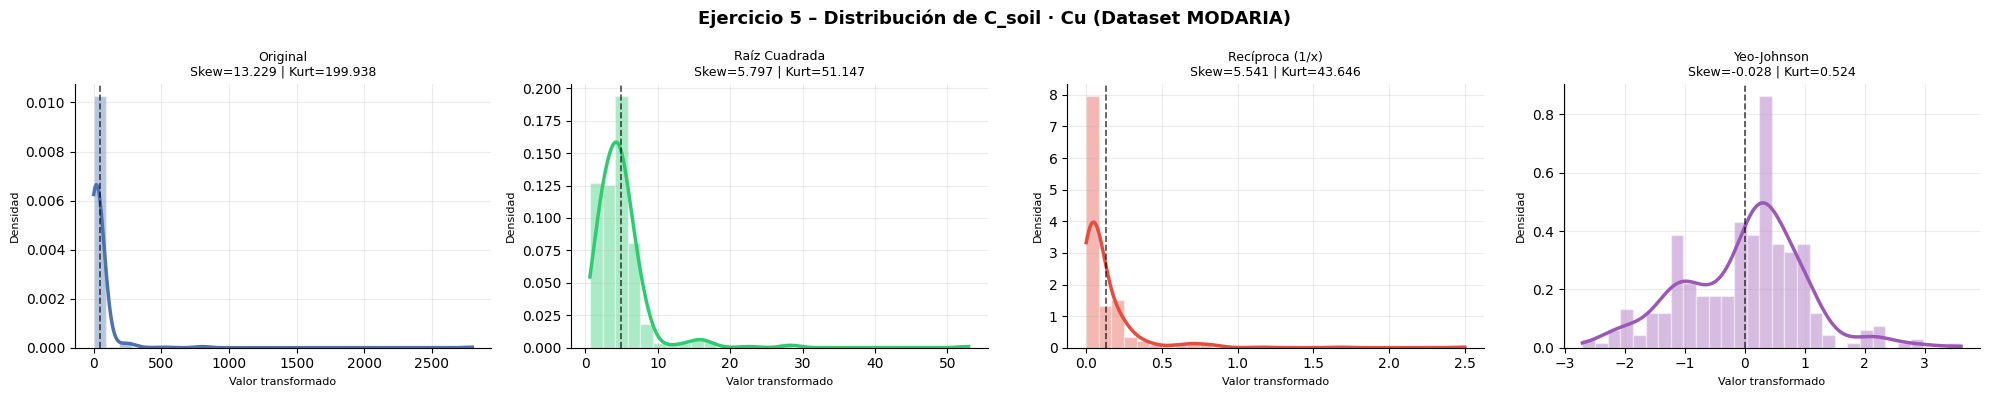

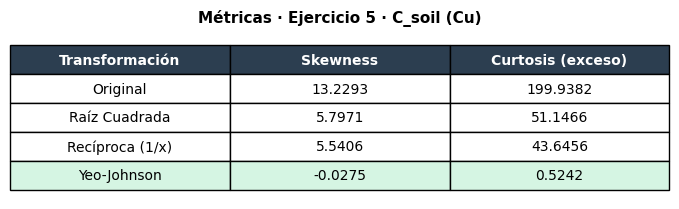

✓ Cu – Ejercicio 5 guardado.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.preprocessing import PowerTransformer

# ── Carga y limpieza ─────────────────────────────────────────────────────────
url = ('https://data.iaea.org/dataset/62358dd9-48b0-4149-a10e-1caa675ddd04/'
       'resource/42c148b5-f43d-4b6f-b521-e4197fc23823/download/'
       'iaea-modaria-ii-tropical-dataset.csv')
df = pd.read_csv(url)

def limpiar(val):
    try: return float(str(val).replace('<', ''))
    except: return np.nan

df['C_soil_n']  = df['C_soil'].apply(limpiar)
df['C_plant_n'] = df['C_plant'].apply(limpiar)

colores = ['#4C72B0', '#2ecc71', '#e74c3c', '#9b59b6']
nombres = ['Original', 'Raíz Cuadrada', 'Recíproca (1/x)', 'Yeo-Johnson']

# ════════════════════════════════════════════════════════════════════════════
# EJERCICIO 5 – Pb
# ════════════════════════════════════════════════════════════════════════════
df_pb = df[(df['Element'] == 'Pb') & (df['C_soil_n'] > 0) & (df['C_plant_n'] > 0)].copy()
x_pb  = df_pb['C_soil_n'].values

pt    = PowerTransformer(method='yeo-johnson')
datos_pb = [x_pb, np.sqrt(x_pb), 1/x_pb,
            pt.fit_transform(x_pb.reshape(-1,1)).flatten()]

metricas_pb = pd.DataFrame({
    'Transformación': nombres,
    'Skewness': [round(stats.skew(d),      4) for d in datos_pb],
    'Curtosis':  [round(stats.kurtosis(d), 4) for d in datos_pb],
})
print("=== Ejercicio 5 · Pb ===")
print(metricas_pb.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Ejercicio 5 – Distribución de C_soil · Pb (Dataset MODARIA)',
             fontsize=13, fontweight='bold')
for ax, d, nombre, color in zip(axes, datos_pb, nombres, colores):
    ax.hist(d, bins=30, density=True, color=color, alpha=0.40, edgecolor='white')
    kde = stats.gaussian_kde(d)
    xs  = np.linspace(d.min(), d.max(), 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2.5)
    ax.axvline(np.mean(d), color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'{nombre}\nSkew={stats.skew(d):.3f} | Kurt={stats.kurtosis(d):.3f}', fontsize=9)
    ax.set_xlabel('Valor transformado', fontsize=8)
    ax.set_ylabel('Densidad', fontsize=8)
    ax.grid(True, alpha=0.25)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ejercicio5_Pb.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 2.2))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[r['Transformación'], f"{r['Skewness']:.4f}", f"{r['Curtosis']:.4f}"] for _, r in metricas_pb.iterrows()],
    colLabels=['Transformación', 'Skewness', 'Curtosis (exceso)'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1.3, 1.8)
for j in range(3):
    tabla[(0,j)].set_facecolor('#2C3E50')
    tabla[(0,j)].set_text_props(color='white', fontweight='bold')
min_idx = metricas_pb['Skewness'].abs().idxmin() + 1
for j in range(3): tabla[(min_idx,j)].set_facecolor('#D5F5E3')
ax2.set_title('Métricas · Ejercicio 5 · C_soil (Pb)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ejercicio5_Pb_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Pb – Ejercicio 5 guardado.")


# ════════════════════════════════════════════════════════════════════════════
# EJERCICIO 5 – Zn
# ════════════════════════════════════════════════════════════════════════════
df_zn = df[(df['Element'] == 'Zn') & (df['C_soil_n'] > 0) & (df['C_plant_n'] > 0)].copy()
x_zn  = df_zn['C_soil_n'].values

pt    = PowerTransformer(method='yeo-johnson')
datos_zn = [x_zn, np.sqrt(x_zn), 1/x_zn,
            pt.fit_transform(x_zn.reshape(-1,1)).flatten()]

metricas_zn = pd.DataFrame({
    'Transformación': nombres,
    'Skewness': [round(stats.skew(d),      4) for d in datos_zn],
    'Curtosis':  [round(stats.kurtosis(d), 4) for d in datos_zn],
})
print("\n=== Ejercicio 5 · Zn ===")
print(metricas_zn.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Ejercicio 5 – Distribución de C_soil · Zn (Dataset MODARIA)',
             fontsize=13, fontweight='bold')
for ax, d, nombre, color in zip(axes, datos_zn, nombres, colores):
    ax.hist(d, bins=30, density=True, color=color, alpha=0.40, edgecolor='white')
    kde = stats.gaussian_kde(d)
    xs  = np.linspace(d.min(), d.max(), 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2.5)
    ax.axvline(np.mean(d), color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'{nombre}\nSkew={stats.skew(d):.3f} | Kurt={stats.kurtosis(d):.3f}', fontsize=9)
    ax.set_xlabel('Valor transformado', fontsize=8)
    ax.set_ylabel('Densidad', fontsize=8)
    ax.grid(True, alpha=0.25)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ejercicio5_Zn.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 2.2))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[r['Transformación'], f"{r['Skewness']:.4f}", f"{r['Curtosis']:.4f}"] for _, r in metricas_zn.iterrows()],
    colLabels=['Transformación', 'Skewness', 'Curtosis (exceso)'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1.3, 1.8)
for j in range(3):
    tabla[(0,j)].set_facecolor('#2C3E50')
    tabla[(0,j)].set_text_props(color='white', fontweight='bold')
min_idx = metricas_zn['Skewness'].abs().idxmin() + 1
for j in range(3): tabla[(min_idx,j)].set_facecolor('#D5F5E3')
ax2.set_title('Métricas · Ejercicio 5 · C_soil (Zn)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ejercicio5_Zn_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Zn – Ejercicio 5 guardado.")


# ════════════════════════════════════════════════════════════════════════════
# EJERCICIO 5 – Cu
# ════════════════════════════════════════════════════════════════════════════
df_cu = df[(df['Element'] == 'Cu') & (df['C_soil_n'] > 0) & (df['C_plant_n'] > 0)].copy()
x_cu  = df_cu['C_soil_n'].values

pt    = PowerTransformer(method='yeo-johnson')
datos_cu = [x_cu, np.sqrt(x_cu), 1/x_cu,
            pt.fit_transform(x_cu.reshape(-1,1)).flatten()]

metricas_cu = pd.DataFrame({
    'Transformación': nombres,
    'Skewness': [round(stats.skew(d),      4) for d in datos_cu],
    'Curtosis':  [round(stats.kurtosis(d), 4) for d in datos_cu],
})
print("\n=== Ejercicio 5 · Cu ===")
print(metricas_cu.to_string(index=False))

fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle('Ejercicio 5 – Distribución de C_soil · Cu (Dataset MODARIA)',
             fontsize=13, fontweight='bold')
for ax, d, nombre, color in zip(axes, datos_cu, nombres, colores):
    ax.hist(d, bins=30, density=True, color=color, alpha=0.40, edgecolor='white')
    kde = stats.gaussian_kde(d)
    xs  = np.linspace(d.min(), d.max(), 300)
    ax.plot(xs, kde(xs), color=color, linewidth=2.5)
    ax.axvline(np.mean(d), color='black', linewidth=1.2, linestyle='--', alpha=0.7)
    ax.set_title(f'{nombre}\nSkew={stats.skew(d):.3f} | Kurt={stats.kurtosis(d):.3f}', fontsize=9)
    ax.set_xlabel('Valor transformado', fontsize=8)
    ax.set_ylabel('Densidad', fontsize=8)
    ax.grid(True, alpha=0.25)
    for spine in ['top', 'right']: ax.spines[spine].set_visible(False)
plt.tight_layout()
plt.savefig('ejercicio5_Cu.png', dpi=150, bbox_inches='tight')
plt.show()

fig2, ax2 = plt.subplots(figsize=(7, 2.2))
ax2.axis('off')
tabla = ax2.table(
    cellText=[[r['Transformación'], f"{r['Skewness']:.4f}", f"{r['Curtosis']:.4f}"] for _, r in metricas_cu.iterrows()],
    colLabels=['Transformación', 'Skewness', 'Curtosis (exceso)'],
    cellLoc='center', loc='center'
)
tabla.auto_set_font_size(False); tabla.set_fontsize(10); tabla.scale(1.3, 1.8)
for j in range(3):
    tabla[(0,j)].set_facecolor('#2C3E50')
    tabla[(0,j)].set_text_props(color='white', fontweight='bold')
min_idx = metricas_cu['Skewness'].abs().idxmin() + 1
for j in range(3): tabla[(min_idx,j)].set_facecolor('#D5F5E3')
ax2.set_title('Métricas · Ejercicio 5 · C_soil (Cu)', fontsize=11, fontweight='bold', pad=10)
plt.tight_layout()
plt.savefig('ejercicio5_Cu_tabla.png', dpi=150, bbox_inches='tight')
plt.show()
print("✓ Cu – Ejercicio 5 guardado.")

Como se ha mostrado anteriormente, los tres elementos siguen un patrón de dispersión similar en sus transformaciones: la raíz cuadrada solo corrige parcialmente cuando la asimetría es moderada, como en el Zn, pero no es suficiente para Pb y Cu, donde los outliers extremos dominan la distribución. La recíproca es la técnica menos confiable, ya que en Zn empeora la asimetría y en Pb y Cu apenas produce mejoras respecto a la raíz cuadrada. La transformación de Yeo-Johnson es la más efectiva en los tres elementos, logrando Skewness cercanos a cero sin importar la severidad de la asimetría original, gracias a su optimización automática del parámetro λ y su compatibilidad con valores cero y negativos. Para variables ambientales de concentración en suelo, en el perfil observado en MODARIA, Yeo-Johnson es la opción más recomendable sin excepción.

# Conclusión

Durante los cinco ejercicios, se observó un patrón estructural consistente en los tres elementos analizados: las distribuciones de C_soil muestran una marcada asimetría positiva, debido a que la mayoría de las muestras se concentran en valores bajos y hay outliers extremos relacionados con sitios con alta contaminación industrial o minera. Este comportamiento es característico de variables ambientales en ecosistemas tropicales.

En cuanto a los métodos de escalamiento, RobustScaler demostró ser el más adecuado para este tipo de datos al usar la mediana y el IQR como referencia, preservando la estructura interna de cada elemento sin que los valores atípicos distorsionen la escala del núcleo de datos.
En la normalización, L1 fue más fácil de interpretar en el contexto de transferencia suelo-planta, ya que permite leer directamente qué proporción del metal total está en el suelo en comparación con la planta. Por otro lado, L2 proporciona una distribución más uniforme, aunque su interpretación es menos directa.

Respecto a las transformaciones para reducir asimetría, Box-Cox fue la más efectiva del Ejercicio 4, llevando el Skewness prácticamente a cero en los tres elementos al optimizar automáticamente el parámetro λ, superando a la transformación logarítmica que, aunque práctica, no presenta los mismos resultados.
Yeo-Johnson fue la recomendada paradel Ejercicio 5 con resultados similares y la ventaja adicional de no requerir que los datos sean estrictamente positivos, lo que la hace más robusta y generalizable.

En conclusion, para el análisis de transferencia suelo-planta de metales pesados en ambientes tropicales con datos de perfil similar al de MODARIA, la combinación más recomendable es RobustScaler para escalar y Yeo-Johnson o Box-Cox para normalizar distribuciones, dado que ambas técnicas son resistentes a los outliers extremos que dominan este tipo de variables ambientales.